<h1>Entrenamiento del Modelo MassBalanceMachine XGBoost — Chile (con regionalización)</h1>

<p style="text-align: justify;">
En este notebook se simula el balance de masa superficial glaciar para <strong>Chile</strong> utilizando un modelo personalizado de
<a href="https://xgboost.readthedocs.io/en/stable/">XGBoost</a>. El modelo está configurado con una función objetivo adaptada para generar
predicciones mensuales a partir de datos observacionales agregados. Se instancia <code>CustomXGBoostRegressor</code> y se entrena con los
datos de estacas previamente preparados. <strong>Todo el flujo está basado en una regionalización explícita del territorio</strong>
(p. ej., “Desert Andes”, “Central Andes”, “North Patagonian Andes”, “South Patagonian Andes”), que se usa para filtrar, entrenar y evaluar.
</p>

<p style="text-align: justify;">
El flujo de trabajo incluye pasos clave basados en la regionalización:
</p>

<ol style="margin-left: 20px; padding-left: 0;">
  <li style="margin-bottom: 10px;">
    <p style="text-align: justify;">
      <strong>Carga y preparación de datos por región:</strong>
      Se crea un <code>DataLoader</code> y se etiqueta cada muestra con su región (según una regla de regionalización, por ejemplo bandas
      latitudinales). Luego se filtran las <em>selected_regions</em> para construir los conjuntos de entrenamiento y prueba. El método
      <code>set_train_test_split</code> devuelve iteradores de índices para ahorrar memoria, y <code>get_cv_split</code> genera las
      particiones para validación cruzada respetando la selección regional.
    </p>
  </li>
  <li style="margin-bottom: 10px;">
    <p style="text-align: justify;">
      <strong>Validación cruzada y entrenamiento del modelo:</strong>
      Con las particiones definidas, se exploran hiperparámetros (vía GridSearchCV o RandomizedSearchCV) y se entrena el modelo.
      Este esquema ofrece una evaluación robusta y comparable entre regiones. Por defecto se usan todos los núcleos de CPU; si se desea,
      se puede ajustar <code>num_jobs</code>.
    </p>
  </li>
  <li style="margin-bottom: 10px;">
    <p style="text-align: justify;">
      <strong>Predicciones agregadas por ID y por región:</strong>
      Tras el entrenamiento, se obtienen predicciones mensuales y se agregan por ID de medición y por región para facilitar la
      comparación inter-regional y el análisis de desempeño dentro de cada zona.
    </p>
  </li>
  <li style="margin-bottom: 10px;">
    <p style="text-align: justify;">
      <strong>Evaluación del modelo (global y por región):</strong>
      Se reportan métricas en el conjunto de prueba tanto a nivel combinado de Chile como desglosadas por región, lo que permite
      cuantificar la precisión del modelo y detectar diferencias de comportamiento entre las unidades regionales.
    </p>
  </li>
</ol>


<h1>Training the MassBalanceMachine XGBoost Model — Chile (with regionalization)</h1>

<p style="text-align: justify;">
This notebook simulates glacier surface mass balance for <strong>Chile</strong> using a custom
<a href="https://xgboost.readthedocs.io/en/stable/">XGBoost</a> model. The model is configured with a task-specific objective to produce
monthly predictions from aggregated observational data. A <code>CustomXGBoostRegressor</code> instance is created and trained with the
stake measurements prepared in earlier notebooks. <strong>The entire workflow is grounded in explicit regionalization</strong>
(e.g., “Desert Andes”, “Central Andes”, “North Patagonian Andes”, “South Patagonian Andes”), which is used to filter, train, and evaluate.
</p>

<p style="text-align: justify;">
The workflow includes region-aware steps:
</p>

<ol style="margin-left: 20px; padding-left: 0;">
  <li style="margin-bottom: 10px;">
    <p style="text-align: justify;">
      <strong>Region-based data loading and preparation:</strong>
      A <code>DataLoader</code> is created and each sample is tagged with its region (based on a regionalization rule, e.g., latitudinal bands).
      The <em>selected_regions</em> are then filtered to build train/test sets. The <code>set_train_test_split</code> method returns
      index iterators to save memory, and <code>get_cv_split</code> generates cross-validation folds that respect the regional selection.
    </p>
  </li>
  <li style="margin-bottom: 10px;">
    <p style="text-align: justify;">
      <strong>Cross-validation and model training:</strong>
      With the folds defined, hyperparameters are explored (via GridSearchCV or RandomizedSearchCV) and the model is trained.
      This scheme yields robust, region-comparable evaluation. By default all CPU cores are used; adjust <code>num_jobs</code> if needed.
    </p>
  </li>
  <li style="margin-bottom: 10px;">
    <p style="text-align: justify;">
      <strong>Aggregated predictions by ID and by region:</strong>
      After training, monthly predictions are produced and aggregated by measurement ID and by region
      to enable inter-regional comparisons and within-region performance analysis.
    </p>
  </li>
  <li style="margin-bottom: 10px;">
    <p style="text-align: justify;">
      <strong>Model evaluation (global and per region):</strong>
      Metrics are reported on the test set for Chile overall and broken down by region, allowing quantification of accuracy
      and detection of behavioral differences across regional units.
    </p>
  </li>
</ol>


In [2]:
import pandas as pd
import massbalancemachine as mbm
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2

In [3]:
# Load monthly dataset and inspect size
# Cargar el dataset mensual y revisar su tamaño
data = pd.read_csv('/mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/files/CL_monthly_dataset.csv')
print('Number of winter and annual samples:', len(data))

# Configure MBM for Chile-specific settings (or use the generic config if preferred)
# Configurar MBM con parámetros específicos para Chile (o usar la configuración genérica si prefieres)
# cfg = mbm.ChileConfig()  # Just for Chile / Solo para Chile
cfg = mbm.ChileConfig()     # Generic / Genérica

# Region classifier based on latitude (simple latitudinal bands)
# Clasificador de regiones basado en latitud (bandas latitudinales simples)
def classify_region(lat):
    if -31 <= lat < -17:
        return "Desert Andes"             # Andes Desérticos
    elif -36 <= lat < -31:
        return "Central Andes"            # Andes Centrales
    elif -45 <= lat < -36:
        return "North Patagonian Andes"   # Andes Norpatagónicos
    elif -55 <= lat < -45:
        return "South Patagonian Andes"   # Andes Sur Patagónicos
    else:
        return "Outside range"            # Fuera de rango

# Add region label to each row using POINT_LAT
# Agregar etiqueta de región a cada fila usando POINT_LAT
data["region"] = data["POINT_LAT"].apply(classify_region)

# Remove a specific glacier (Exploradores) from the analysis
# Remover un glaciar específico (Exploradores) del análisis
#data = data[data['RGIId'] != 'RGI60-17.15831']

# Quick sanity check after filtering
# Revisión rápida después del filtrado
display(data)


Number of winter and annual samples: 2702


,YEAR,POINT_LON,POINT_LAT,POINT_BALANCE,ALTITUDE_CLIMATE,ELEVATION_DIFFERENCE,POINT_ELEVATION,RGIId,POINT_ID,ID,...,aspect,slope,t2m,tp,slhf,sshf,ssrd,fal,str,region
0,2022,-71.413294,-36.834797,-11.340,1175.040894,1675.175106,2850.216,RGI60-17.13045,B1,0,...,4.722618,0.446868,282.910156,0.000786,-6070985.0,-8909182.0,29207030.0,0.226196,-7138438.0,North Patagonian Andes
1,2022,-71.413294,-36.834797,-11.340,1175.040894,1675.175106,2850.216,RGI60-17.13045,B1,0,...,4.722618,0.446868,286.708740,0.000892,-5621875.0,-11652478.0,31848896.0,0.194438,-7765883.0,North Patagonian Andes
2,2022,-71.413294,-36.834797,-11.340,1175.040894,1675.175106,2850.216,RGI60-17.13045,B1,0,...,4.722618,0.446868,286.497803,0.000850,-4643900.0,-13107320.0,30782500.0,0.167194,-7547407.0,North Patagonian Andes
3,2022,-71.413294,-36.834797,-11.340,1175.040894,1675.175106,2850.216,RGI60-17.13045,B1,0,...,4.722618,0.446868,286.342041,0.000884,-3513949.0,-12132404.0,27747924.0,0.144828,-7983862.0,North Patagonian Andes
4,2022,-71.413294,-36.834797,-11.340,1175.040894,1675.175106,2850.216,RGI60-17.13045,B1,0,...,4.722618,0.446868,284.131104,0.000595,-3106384.0,-8918145.0,22504258.0,0.128708,-7610646.0,North Patagonian Andes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2697,2020,-70.869300,-54.398270,-6.867,240.920654,-39.920654,201.000,RGI60-17.03160,1-centralbal,817,...,0.800561,0.378918,276.089600,0.008428,-5292936.0,1883227.0,12206191.0,0.318630,-3333433.0,South Patagonian Andes
2698,2020,-70.869300,-54.398270,-6.867,240.920654,-39.920654,201.000,RGI60-17.03160,1-centralbal,817,...,0.800561,0.378918,277.700195,0.009965,-6643323.0,-1608046.0,17374222.0,0.223969,-3686090.0,South Patagonian Andes
2699,2020,-70.869300,-54.398270,-6.867,240.920654,-39.920654,201.000,RGI60-17.03160,1-centralbal,817,...,0.800561,0.378918,279.432617,0.011624,-8756558.0,-1488746.0,16184760.0,0.134906,-3143952.0,South Patagonian Andes
2700,2020,-70.869300,-54.398270,-6.867,240.920654,-39.920654,201.000,RGI60-17.03160,1-centralbal,817,...,0.800561,0.378918,280.186523,0.013636,-8641762.0,-856350.0,14689522.0,0.132848,-2836048.0,South Patagonian Andes


In [4]:
import pandas as pd
# Load/assume master DataFrame 'data' with a 'region' column
# Cargar/asumir DataFrame maestro 'data' con una columna 'region'

df = data
# Create a working alias to avoid mutating the original df
# Crear un alias de trabajo para no mutar el DataFrame original

REGION = "South Patagonian Andes"
# Region to filter (case-insensitive)
# Región a filtrar (insensible a mayúsculas/minúsculas)

col = "RGIId"
# ID column whose unique codes you want to list
# Columna de ID cuyos códigos únicos deseas listar

# Build boolean mask for REGION (trim + casefold for robustness)
# Construir máscara booleana para REGION (recorte + casefold para robustez)
mask_region = df["region"].astype(str).str.strip().str.casefold().eq(REGION.casefold())

# Slice and copy subset safely (avoid SettingWithCopy issues)
# Seleccionar y copiar el subconjunto de forma segura (evitar SettingWithCopy)
df_spa = df.loc[mask_region].copy()

# Extract cleaned unique codes: dropna → cast to str → strip → unique
# Extraer códigos únicos limpios: dropna → convertir a str → strip → unique
unique_codes = (
    df_spa[col]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

# Print header with count
# Imprimir encabezado con conteo
print(f"{col} únicos en {REGION} (n={len(unique_codes)}):")

# Print codes in sorted order
# Imprimir códigos en orden ascendente
for v in sorted(unique_codes):
    print(v)


RGIId únicos en South Patagonian Andes (n=5):
RGI60-17.00312
RGI60-17.03160
RGI60-17.04856
RGI60-17.04871
RGI60-17.15831


ES: Se crea el `DataLoader`, que construye los conjuntos de entrenamiento y prueba y define las divisiones para la validación cruzada. Para ahorrar memoria, `set_train_test_split` devuelve iteradores con los índices de train/test; con esos índices se recuperan las filas reales durante el entrenamiento y la evaluación. Luego, `get_cv_split` proporciona la lista de particiones (k-folds) que se emplearán en la validación cruzada.

EN: The `DataLoader` is created to build the training and test sets and to define the splits for cross-validation. To save memory, `set_train_test_split` returns iterators containing the train/test indices; those indices are then used to fetch the actual rows during training and evaluation. Next, `get_cv_split` supplies the list of partitions (k-folds) to run the cross-validation.


In [6]:
# Select regions, then apply your standard MBM splits (Chile)
# Seleccionar regiones y luego aplicar tus particiones estándar de MBM

# 1) Filter to selected regions first
# 1) Filtrar primero a las regiones seleccionadas
selected_regions = ["Desert Andes","Central Andes","North Patagonian Andes","South Patagonian Andes"]  # <- edit as needed / editar según necesidad
if "region" not in data.columns:
    raise KeyError("Column 'region' not found in DataFrame.")
    # Si no existe la columna 'region', se detiene con error

df_sub = data[data["region"].astype(str).str.strip().isin({r.strip() for r in selected_regions})].copy()
# Mantiene solo filas cuya 'region' está en selected_regions (tolerante a espacios y tipos)
if df_sub.empty:
    raise ValueError(f"No rows found for selected regions: {selected_regions}")
    # Si el filtro deja el DataFrame vacío, se avisa con un error claro

print("Filtered subset size:", len(df_sub))
print("Subset region distribution:")
print(df_sub["region"].value_counts().to_string())
# Reporte rápido del tamaño del subconjunto y distribución por región
# Quick report of subset size and per-region distribution

# 2) Create DataLoader on the filtered subset
# 2) Crear el DataLoader sobre el subconjunto filtrado
dataloader = mbm.DataLoader(cfg, data=df_sub)

# 3) Your usual split (indices are RELATIVE to df_sub)
# 3) Partición habitual (los índices son RELATIVOS a df_sub)
#    You can pass other params if your API supports them
#    Puedes pasar otros parámetros si tu API los soporta
train_itr, test_itr = dataloader.set_train_test_split(test_size=0.3)

# 4) Extract indices (relative to df_sub)
# 4) Extraer índices (relativos a df_sub)
train_indices_sub, test_indices_sub = list(train_itr), list(test_itr)

# Optional: map to ORIGINAL indices from `data` if needed later
# Opcional: mapear a índices ORIGINALES de `data` si los necesitas luego
orig_index_array = df_sub.index.to_numpy()
train_indices_orig = orig_index_array[train_indices_sub].tolist()
test_indices_orig  = orig_index_array[test_indices_sub].tolist()

# 5) Build X/y using the SUBSET (recommended to stay consistent with the DataLoader)
# 5) Construir X/y usando el SUBCONJUNTO (recomendado para ser consistente con el DataLoader)
#    Note: usually you should drop 'region' from features to avoid leakage
#    Nota: normalmente deberías quitar 'region' de las features para evitar fuga de información
# df_X_train = df_sub.iloc[train_indices_sub].drop(columns=["region"])
df_X_train = df_sub.iloc[train_indices_sub]
y_train    = df_X_train["POINT_BALANCE"].values

# df_X_test  = df_sub.iloc[test_indices_sub].drop(columns=["region"])
df_X_test  = df_sub.iloc[test_indices_sub]
y_test     = df_X_test["POINT_BALANCE"].values

# 6) Cross-validation splits from the DataLoader (on the subset)
# 6) Splits de validación cruzada desde el DataLoader (en el subconjunto)
splits = dataloader.get_cv_split(n_splits=5)

# 7) Report sizes
# 7) Reportar tamaños
print(f"Regions used: {selected_regions}")
print(f"Size of training set: {len(train_indices_sub)}")
print(f"Size of test set: {len(test_indices_sub)}")

# Optional: show region distribution inside each split
# Opcional: mostrar la distribución por región dentro de cada split
print("\nTrain region distribution (subset):")
print(df_sub.iloc[train_indices_sub]["region"].value_counts().to_string())
print("\nTest region distribution (subset):")
print(df_sub.iloc[test_indices_sub]["region"].value_counts().to_string())

# If you MUST keep working on the full `data` with original indices, use these:
# Si DEBES seguir trabajando con `data` completa y los índices originales, usa esto:
# df_X_train_full = data.loc[train_indices_orig].drop(columns=["region"])
# y_train_full    = df_X_train_full["POINT_BALANCE"].values
# df_X_test_full  = data.loc[test_indices_orig].drop(columns=["region"])
# y_test_full     = df_X_test_full["POINT_BALANCE"].values


Filtered subset size: 2702
Subset region distribution:
region
North Patagonian Andes    1307
South Patagonian Andes     637
Central Andes              618
Desert Andes               140
Regions used: ['Desert Andes', 'Central Andes', 'North Patagonian Andes', 'South Patagonian Andes']
Size of training set: 1922
Size of test set: 780

Train region distribution (subset):
region
North Patagonian Andes    963
South Patagonian Andes    460
Central Andes             399
Desert Andes              100

Test region distribution (subset):
region
North Patagonian Andes    344
Central Andes             219
South Patagonian Andes    177
Desert Andes               40


<h2>2. Crear un Modelo CustomXGBoostRegressor</h2>
<p style='text-align: justify;'>
A continuación, definimos los rangos de parámetros para cada parámetro de XGBoost. En el paso siguiente, utilizamos la validación cruzada para explorar estos rangos de parámetros y seleccionar la combinación que produzca la menor pérdida. Además, creamos un objeto <code>CustomXGBoostRegressor</code>.
</p>

In [7]:
# Grid search
# For each of the XGBoost parameter, define the grid range
parameters = {
    'max_depth': [
        3,
        4,
        5,
        6,
    ],
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
    'n_estimators': [100, 200,300],
    'gamma': [0,1]
}

params_init = {"device": "cpu"}
custom_xgboost = mbm.models.CustomXGBoostRegressor(cfg, **params_init)


In [8]:
vois_climate = [
    't2m', 'tp', 'slhf', 'sshf', 'ssrd', 'fal', 'str'
]

vois_topographical = [
    "aspect",
    "slope"
]


# Feature columns:
feature_columns = [
    'ELEVATION_DIFFERENCE'
] + list(vois_climate) + list(vois_topographical) 
all_columns = feature_columns + cfg.fieldsNotFeatures

df_X_train = df_X_train[all_columns]
print('Shape of training dataset:', df_X_train.shape)
print('Shape of testing dataset:', df_X_test[all_columns].shape)
print('Running with features:', feature_columns)

Shape of training dataset: (1922, 21)
Shape of testing dataset: (780, 21)
Running with features: ['ELEVATION_DIFFERENCE', 't2m', 'tp', 'slhf', 'sshf', 'ssrd', 'fal', 'str', 'aspect', 'slope']


<h2>3. Entrenar el Modelo CustomXGBoostRegressor</h2>

<p style='text-align: justify; margin-bottom: 5px;'>
En la siguiente celda, comenzamos el entrenamiento de nuestro modelo utilizando <strong>GridSearchCV</strong> o <strong>RandomizedSearchCV</strong>:
</p>

<ul style="margin-left: 20px; padding-left: 0; margin-bottom: 5px;">
  <li style="margin-bottom: 10px;">
    <p style='text-align: justify;'><strong>GridSearchCV</strong> realiza una búsqueda exhaustiva entre todas las combinaciones posibles de parámetros para encontrar el mejor conjunto que ofrezca el rendimiento óptimo utilizando validación cruzada. Aunque este método es minucioso, suele ser lento y computacionalmente costoso.</p>
  </li>
  <li style="margin-bottom: 0px;">
    <p style='text-align: justify;'><strong>RandomizedSearchCV</strong>, por otro lado, selecciona un número fijo de combinaciones de parámetros de la distribución, lo que lo hace más eficiente en términos de tiempo y recursos computacionales, especialmente en espacios de hiperparámetros grandes. Sin embargo, este enfoque puede omitir algunas de las mejores combinaciones de parámetros que no sean seleccionadas aleatoriamente.</p>
  </li>
</ul>

<p style='text-align: justify;'>
Puedes elegir cualquiera de los dos métodos de entrenamiento. Ambos métodos utilizarán todos los núcleos de la CPU por defecto. Si deseas ajustar el número de núcleos utilizados, puedes cambiar el parámetro <code>num_jobs</code>.
</p>


In [9]:
# Optional exhaustive grid search (commented out for speed)
# Búsqueda exhaustiva en grilla (comentada por velocidad)
# custom_xgboost.gridsearch(parameters=parameters, splits=splits, features=df_X_train, targets=y_train, num_jobs=-1)

# Randomized search: sample n_iter combos (speed vs. quality trade-off)
# Búsqueda aleatoria: muestrea n_iter combinaciones (compromiso velocidad vs. calidad)
custom_xgboost.randomsearch(
    parameters=parameters,
    n_iter=45,
    splits=splits,
    features=df_X_train,
    targets=y_train,
)

# Extract best hyperparameters from the search
# Extraer los mejores hiperparámetros de la búsqueda
best_params = custom_xgboost.param_search.best_params_

# Retrieve the best fitted estimator
# Recuperar el mejor estimador ajustado
best_estimator = custom_xgboost.param_search.best_estimator_

# Log best configuration for reproducibility
# Registrar la mejor configuración para reproducibilidad
print("Best parameters:\n", best_params)

# Report the best cross-validation score achieved
# Reportar el mejor puntaje de validación cruzada alcanzado
print("Best score:\n", custom_xgboost.param_search.best_score_)


Fitting 5 folds for each of 45 candidates, totalling 225 fits


/home/duilio/miniconda3/envs/MassBalanceMachine/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [17:50:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "cfg" } are not used.

  warnings.warn(smsg, UserWarning)
/home/duilio/miniconda3/envs/MassBalanceMachine/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [17:50:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "cfg" } are not used.

  warnings.warn(smsg, UserWarning)
/home/duilio/miniconda3/envs/MassBalanceMachine/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [17:50:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "cfg" } are not used.

  warnings.warn(smsg, UserWarning)
/home/duilio/miniconda3/envs/MassBalanceMachine/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [17:50:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "cfg" } are not used.

  warnings.warn(smsg, UserWarning)
/home/duilio/miniconda3/envs/MassBalanceMachine/lib/python3.

Best parameters:
 {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 1}
Best score:
 -2.7533026347040552


In [9]:
custom_xgboost.save_model('/mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/entrenamientos/model_xgb_DA_CA_NP_SP.pkl')

In [9]:
#mbm.models.CustomXGBoostRegressor.load_model('model_xgb.pkl')

In [11]:
# Configure best estimator to use CPU for inference
# Configurar el mejor estimador para usar CPU en inferencia
xgb = best_estimator.set_params(device='cpu')

# Build test features and metadata from the test DataFrame
# Construir features y metadatos de prueba desde el DataFrame de test
features_test, metadata_test = xgb._create_features_metadata(df_X_test[all_columns])

# Row-level predictions on test features
# Predicciones a nivel de fila sobre las features de test
y_pred = xgb.predict(features_test)

# Aggregate predictions by measurement ID using model helper
# Agregar predicciones por ID de medición usando el helper del modelo
y_pred_agg = xgb.aggrPredict(metadata_test, features_test)

# Compute scores/metrics (note: score may be negative depending on definition)
# Calcular puntajes/métricas (nota: el score puede ser negativo según la definición)
score = xgb.score(df_X_test[all_columns], y_test)  # negativo
mse, rmse, mae, pearson = xgb.evalMetrics(metadata_test, y_pred, y_test)

# Build DataFrame with targets and aggregate to annual/winter scale by ID
# Construir DataFrame con objetivos y agregar a escala anual/invernal por ID
df_pred = df_X_test[all_columns].copy()
df_pred['target'] = y_test
grouped_ids = df_pred.groupby('ID').agg({'target': 'mean'})

# Attach aggregated predictions aligned with grouped IDs
# Adjuntar predicciones agregadas alineadas con los IDs agrupados
grouped_ids['pred'] = y_pred_agg


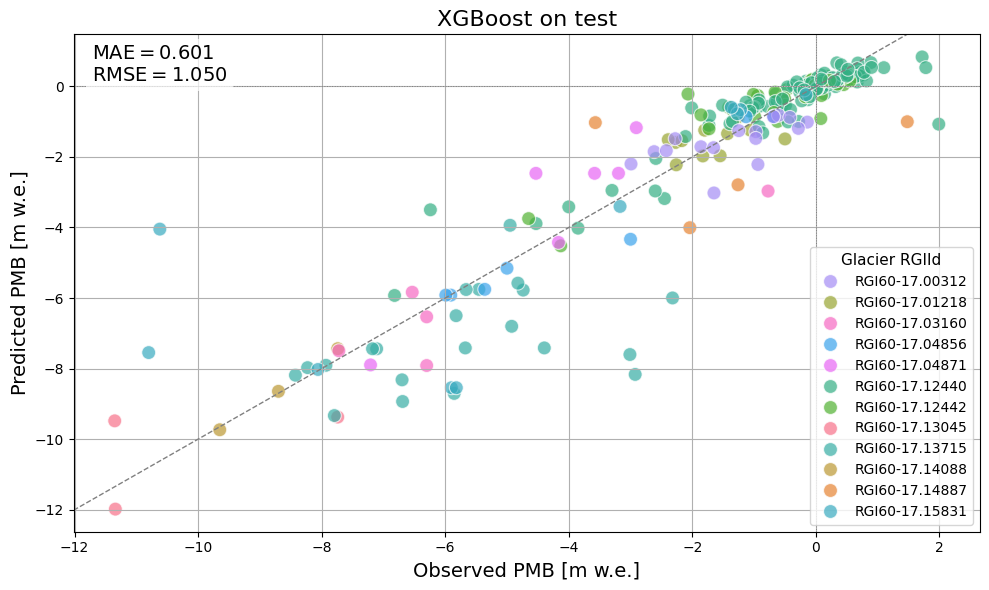

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
# Plotting libraries
# Librerías para graficar

# Aggregate target by ID and attach predictions + glacier code
# Agregar el target por ID y anexar predicciones + código de glaciar
df_pred_agg = df_pred.groupby('ID').agg({'target': 'mean'}).copy()
df_pred_agg['pred'] = y_pred_agg
df_pred_agg['RGIId'] = df_pred.groupby('ID')['RGIId'].first()
grouped_ids = df_pred_agg.reset_index()

# Prepare metrics text for annotation box
# Preparar el texto de métricas para el recuadro de anotación
legend_text = (
    rf"$\mathrm{{MAE}} = {mae:.3f}$" + "\n" +
    rf"$\mathrm{{RMSE}} = {rmse:.3f}$"
)

# Build a color palette per glacier (one hue per RGIId)
# Construir una paleta de color por glaciar (un color por RGIId)
unique_rgi = grouped_ids['RGIId'].nunique()
palette = sns.color_palette("husl", unique_rgi)

# Figure and axis
# Figura y ejes
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter of observed vs predicted, colored by glacier
# Dispersión de observado vs predicho, coloreado por glaciar
sns.scatterplot(
    data=grouped_ids,
    x='target',
    y='pred',
    hue='RGIId',
    palette=palette,
    s=100,
    alpha=0.7,
    ax=ax
)

# 1:1 diagonal reference line
# Línea de referencia diagonal 1:1
ax.axline((0, 0), slope=1, color='grey', linestyle='--', linewidth=1)

# Zero reference lines on axes
# Líneas de referencia en cero en los ejes
ax.axvline(0, color="grey", linestyle=":", linewidth=0.7)
ax.axhline(0, color="grey", linestyle=":", linewidth=0.7)

# Labels and title
# Etiquetas y título
ax.set_xlabel('Observed PMB [m w.e.]', fontsize=14)
ax.set_ylabel('Predicted PMB [m w.e.]', fontsize=14)
ax.set_title('XGBoost on test', fontsize=16)

# Metrics annotation box
# Recuadro de anotación con métricas
ax.text(0.02, 0.98, legend_text,
        transform=ax.transAxes,
        verticalalignment='top',
        fontsize=14,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Sorted legend for readability
# Leyenda ordenada para mejor legibilidad
handles, labels = ax.get_legend_handles_labels()
order = sorted(range(len(labels)), key=lambda i: labels[i])
ax.legend([handles[i] for i in order], [labels[i] for i in order],
          title='Glacier RGIId', fontsize=10, title_fontsize=11)

# Grid, layout, save, and show
# Cuadrícula, ajuste, guardar y mostrar
ax.grid(True)
plt.tight_layout()
plt.savefig("xgb_test_performance.png", dpi=300)
plt.show()


Selected regions distribution:
 region
North Patagonian Andes    1307
South Patagonian Andes     637
Central Andes              618
Desert Andes               140

Selected regions ['Desert Andes', 'Central Andes', 'North Patagonian Andes', 'South Patagonian Andes'] — metrics:
 {'mse': 0.45613525347240275, 'rmse': 0.6753778597736253, 'mae': 0.397388882420939, 'pearson': 0.972936715988307, 'score': -0.45613525347240275}
✓ Plot saved to: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP/plot_selected_regions_DesertAndes_CentralAndes_NorthPatagonianAndes_SouthPatagonianAndes_20250827_103557.png


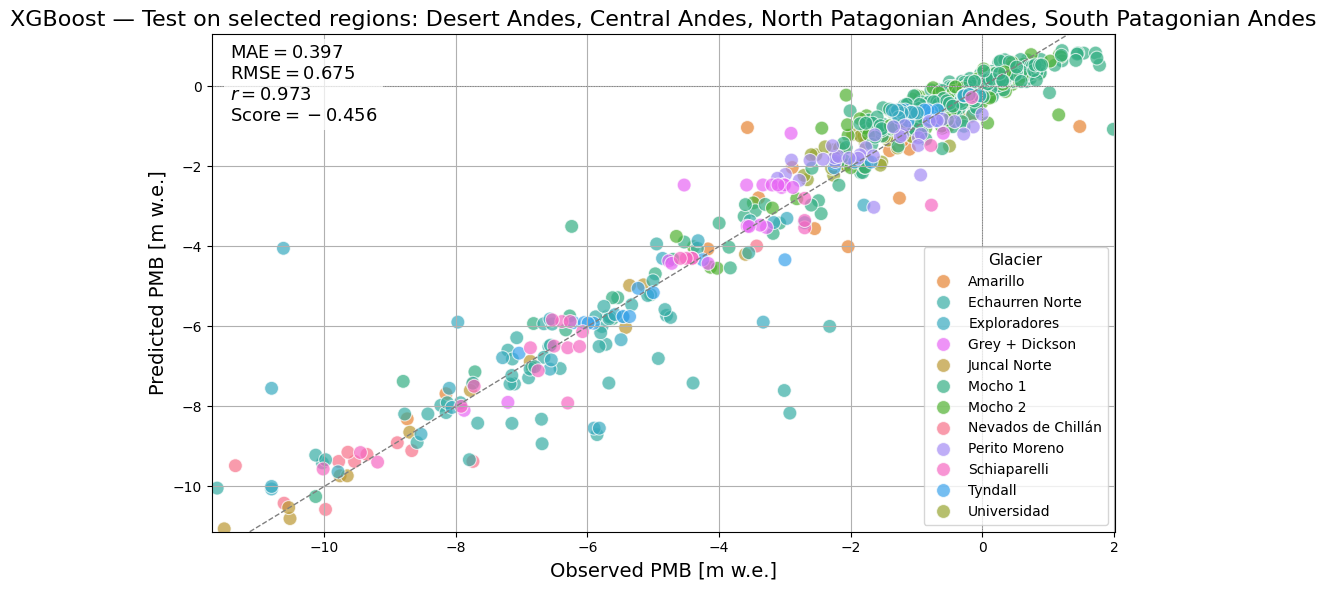

✓ Plot saved to: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP/plot_DesertAndes_20250827_103557.png


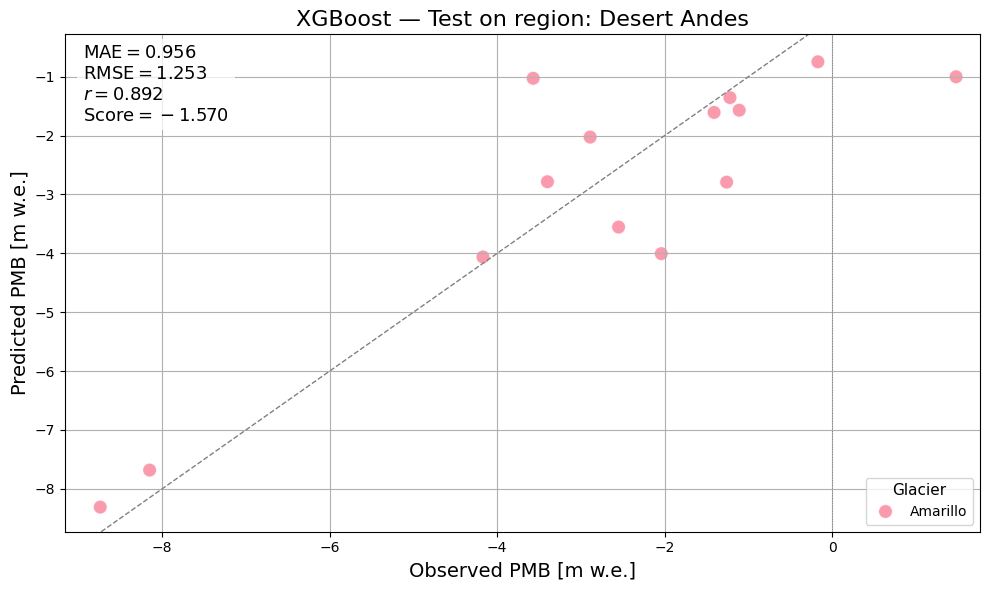

✓ Plot saved to: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP/plot_CentralAndes_20250827_103557.png


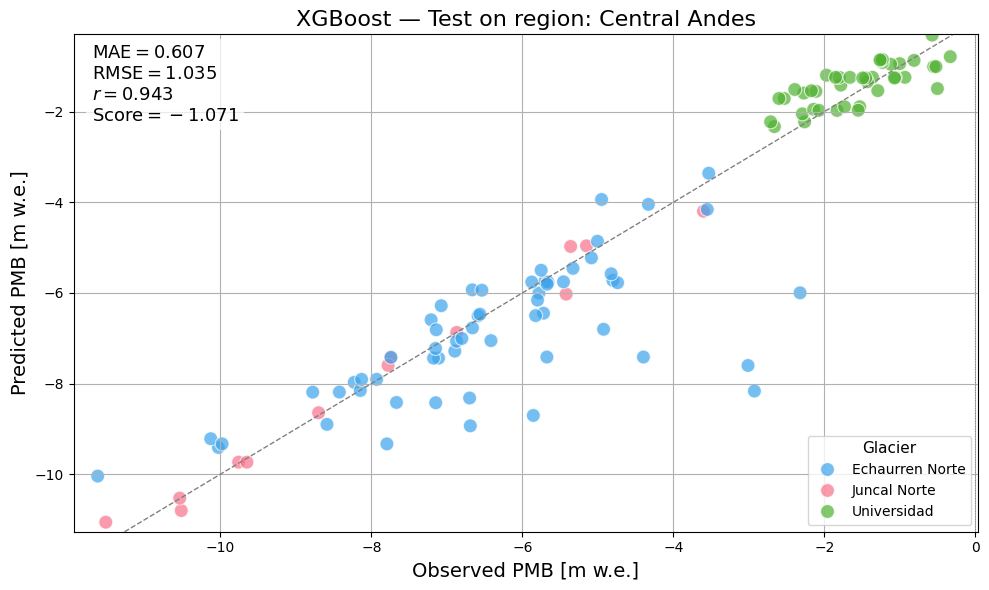

✓ Plot saved to: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP/plot_NorthPatagonianAndes_20250827_103557.png


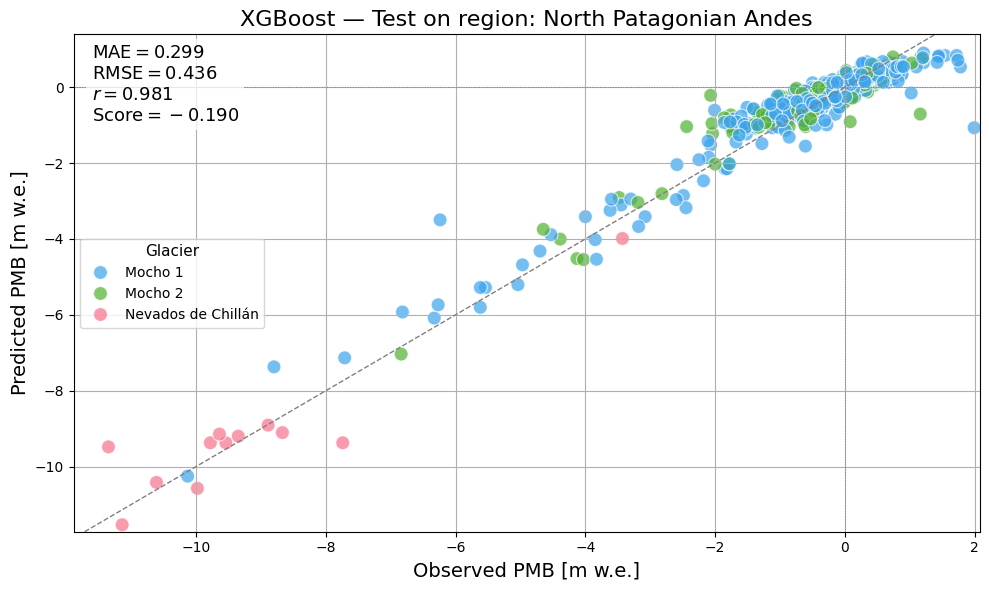

✓ Plot saved to: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP/plot_SouthPatagonianAndes_20250827_103557.png


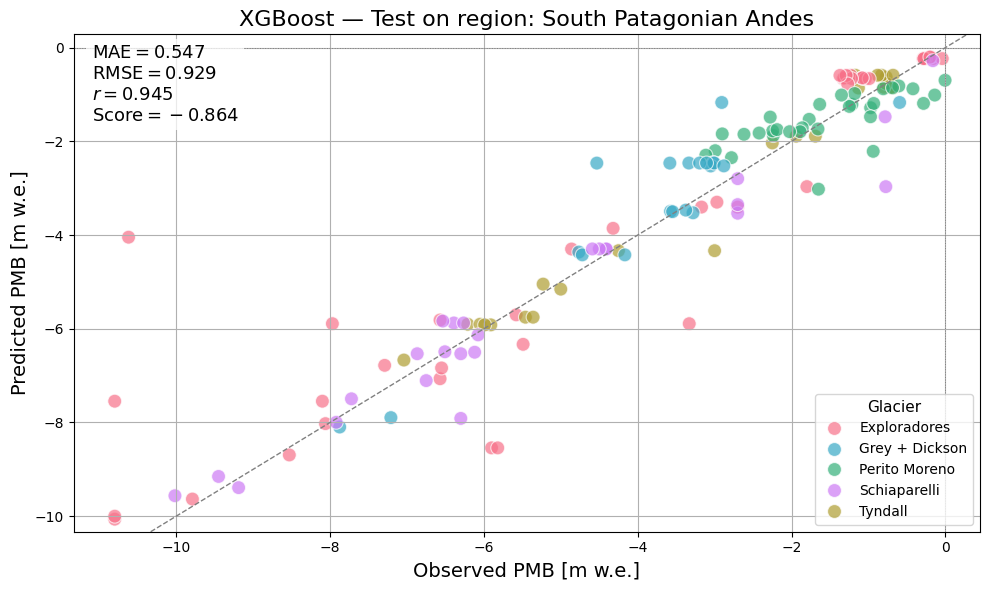


Selected per-region summary (sorted by RMSE):
                region      mse     rmse      mae  pearson     score
North Patagonian Andes 0.189771 0.435627 0.299020 0.980524 -0.189771
South Patagonian Andes 0.863507 0.929251 0.547384 0.944775 -0.863507
         Central Andes 1.070512 1.034656 0.606675 0.943449 -1.070512
          Desert Andes 1.570001 1.252997 0.955544 0.891532 -1.570001

✓ Row-level predictions saved to: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/DA_CA_NP_SP/pred_rows_DesertAndes_CentralAndes_NorthPatagonianAndes_SouthPatagonianAndes_20250827_103557.csv
✓ Aggregated-by-ID (combined) saved to: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/DA_CA_NP_SP/pred_agg_byID_DesertAndes_CentralAndes_NorthPatagonianAndes_SouthPatagonianAndes_20250827_103557.csv
✓ Per-region metrics saved to: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/DA_CA_NP_SP/metrics_per_region_DesertAndes_Cen

In [ ]:
import os
import re
from datetime import datetime

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import load
# Load libs for IO, math, plotting, and model deserialization
# Cargar librerías para E/S, matemáticas, gráficos y deserialización de modelos

def ensure_best_estimator(obj):
    """Return best_estimator_ if obj is a CV wrapper; otherwise obj."""
    # Devuelve best_estimator_ si obj es un envoltorio de CV; de lo contrario obj.
    return getattr(obj, 'best_estimator_', obj)

def make_test_from_regions(data, regions):
    """
    Build X_test/y_test from rows whose region IS in `regions`.
    You explicitly choose which regions to analyze.
    """
    # Construye X_test/y_test con filas cuya región ESTÁ en `regions`.
    # Permite elegir explícitamente qué regiones analizar.
    if isinstance(regions, str):
        regions = [regions]
    wanted = {r.strip() for r in regions}
    df_sel = data[data['region'].astype(str).str.strip().isin(wanted)].copy()
    if df_sel.empty:
        raise ValueError(f"No rows found for selected regions: {sorted(wanted)}")
    X_sel = df_sel[all_columns]
    y_sel = df_sel['POINT_BALANCE'].values
    return df_sel, X_sel, y_sel

def aggregate_predictions_by_id(df_X, y_pred_id_level, id_col='ID', glacier_col='RGIId', y_true=None):
    """
    Build a tidy df with ['ID','target','pred','RGIId'] aggregated at ID level.
    `y_pred_id_level` must already be aggregated per ID (same order as your model helper uses).
    """
    # Construye un df ordenado con ['ID','target','pred','RGIId'] agregados a nivel ID.
    # `y_pred_id_level` debe venir ya agregado por ID (mismo orden que usa el helper del modelo).
    tmp = df_X.copy()
    if y_true is not None:
        tmp['target'] = y_true
    df_agg = tmp.groupby(id_col, as_index=False).agg({'target': 'mean'})
    df_agg['pred'] = y_pred_id_level
    df_agg[glacier_col] = tmp.groupby(id_col)[glacier_col].first().values
    return df_agg

def plot_obs_vs_pred(grouped_ids, rgi_to_name=None, title='XGBoost — Selected regions',
                     annotate_metrics=None, xlim=None, ylim=None, savepath=None):
    """Scatter 1:1 aggregated by ID with hue by glacier name."""
    # Dispersión 1:1 agregada por ID con color por nombre de glaciar.
    df = grouped_ids.copy()
    rgi_to_name = rgi_to_name or {}
    df['GlacierName'] = df['RGIId'].map(rgi_to_name).fillna(df['RGIId'])

    # Auto limits if not provided
    # Límites automáticos si no se proporcionan
    if xlim is None:
        qx = np.nanpercentile(df['target'], [1, 99]); pad = max(0.5, 0.05*(qx[1]-qx[0]+1e-6))
        xlim = (qx[0]-pad, qx[1]+pad)
    if ylim is None:
        qy = np.nanpercentile(df['pred'], [1, 99]); pad = max(0.5, 0.05*(qy[1]-qy[0]+1e-6))
        ylim = (qy[0]-pad, qy[1]+pad)

    # Palette and scatter
    # Paleta y gráfica de dispersión
    palette = sns.color_palette("husl", df['GlacierName'].nunique())
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.scatterplot(data=df, x='target', y='pred', hue='GlacierName',
                    palette=palette, s=100, alpha=0.7, ax=ax)

    # 1:1 and helpers
    # Línea 1:1 y guías
    ax.axline((0, 0), slope=1, color='grey', linestyle='--', linewidth=1)
    ax.axvline(0, color="grey", linestyle=":", linewidth=0.7)
    ax.axhline(0, color="grey", linestyle=":", linewidth=0.7)

    # Labels and limits
    # Etiquetas y límites
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Observed PMB [m w.e.]', fontsize=14)
    ax.set_ylabel('Predicted PMB [m w.e.]', fontsize=14)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)

    # Optional metrics box
    # Cuadro opcional de métricas
    if annotate_metrics is not None:
        txt = []
        if 'mae' in annotate_metrics:   txt.append(rf"$\mathrm{{MAE}} = {annotate_metrics['mae']:.3f}$")
        if 'rmse' in annotate_metrics:  txt.append(rf"$\mathrm{{RMSE}} = {annotate_metrics['rmse']:.3f}$")
        if 'pearson' in annotate_metrics and annotate_metrics['pearson'] is not None:
            txt.append(rf"$r = {annotate_metrics['pearson']:.3f}$")
        if 'score' in annotate_metrics:
            txt.append(rf"$\mathrm{{Score}} = {annotate_metrics['score']:.3f}$")
        ax.text(0.02, 0.98, "\n".join(txt), transform=ax.transAxes, va='top',
                fontsize=13, bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))

    # Sorted legend
    # Leyenda ordenada
    handles, labels = ax.get_legend_handles_labels()
    order = sorted(range(len(labels)), key=lambda i: labels[i])
    ax.legend([handles[i] for i in order], [labels[i] for i in order],
              title='Glacier', fontsize=10, title_fontsize=11, loc='best')

    ax.grid(True); plt.tight_layout()
    if savepath:
        # Ensure destination folder and save
        # Asegurar carpeta destino y guardar
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=300)
        print(f'✓ Plot saved to: {savepath}')
    plt.show()
    return fig, ax

def slugify(s: str) -> str:
    """Safe token for filenames."""
    # Token seguro para nombres de archivo.
    return re.sub(r'[^A-Za-z0-9]+', '', s)

 
# Load trained model + paths
# Cargar modelo entrenado + rutas
 

obj = load('/mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/entrenamientos/model_xgb_DA_CA_NP_SP.pkl')
# Deserialize model from disk
# Deserializa el modelo desde disco

out_dir  = '/mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/DA_CA_NP_SP'
fig_path = '/mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP'
os.makedirs(out_dir, exist_ok=True)
os.makedirs(fig_path, exist_ok=True)
# Prepare output folders
# Preparar carpetas de salida

xgb = ensure_best_estimator(obj)
if hasattr(xgb, 'set_params'):
    xgb = xgb.set_params(device='cpu')
# Use CPU for inference (if supported)
# Usar CPU para inferencia (si es compatible)

 
# Choose EXACT regions to analyze
# Elegir EXACTAMENTE las regiones a analizar
 
# Valid names: "Desert Andes", "Central Andes", "North Patagonian Andes", "South Patagonian Andes"
# Nombres válidos: "Desert Andes", "Central Andes", "North Patagonian Andes", "South Patagonian Andes"
analyze_regions = ["Desert Andes", "Central Andes", "North Patagonian Andes","South Patagonian Andes"]

# Timestamp and region tag for filenames
# Marca de tiempo y etiqueta de regiones para nombres de archivo
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
regions_tag = "_".join(slugify(r) for r in analyze_regions)

df_sel, X_sel, y_sel = make_test_from_regions(
    data, analyze_regions
)
# Build selected test subset (X/y) by regions
# Construir subconjunto de prueba (X/y) por regiones seleccionadas

print("Selected regions distribution:\n", df_sel['region'].value_counts().to_string())
# Quick distribution report
# Reporte rápido de distribución

 
# Predict, aggregate, metrics (combined selection)
# Predecir, agregar y métricas (selección combinada)
 

features_sel, metadata_sel = xgb._create_features_metadata(X_sel)
y_pred_sel = xgb.predict(features_sel)
y_pred_sel_agg = xgb.aggrPredict(metadata_sel, features_sel)
# Row-level prediction then aggregation by ID
# Predicción por fila y luego agregado por ID

mse, rmse, mae, pearson = xgb.evalMetrics(metadata_sel, y_pred_sel, y_sel)
metrics_sel = {'mse': mse, 'rmse': rmse, 'mae': mae, 'pearson': pearson, 'score': xgb.score(X_sel, y_sel)}
print(f"\nSelected regions {analyze_regions} — metrics:\n", metrics_sel)
# Compute and log metrics/score for the combined selection
# Calcular y registrar métricas/puntaje para la selección combinada

grouped_sel = aggregate_predictions_by_id(
    df_X=X_sel, y_pred_id_level=y_pred_sel_agg,
    id_col='ID', glacier_col='RGIId', y_true=y_sel
)
# Build ID-level tidy table for plotting/export
# Construir tabla ordenada a nivel ID para graficar/exportar

 
# Plot (combined)  -> SAVE IN figs
# Gráfico (combinado) -> GUARDAR en figs
 

rgi_to_name = {
    "RGI60-17.12440": "Mocho 1",
    "RGI60-17.12442": "Mocho 2",
    "RGI60-17.13045": "Nevados de Chillán",
    "RGI60-17.01218": "Universidad",
    "RGI60-17.14088": "Juncal Norte",
    "RGI60-17.14887": "Amarillo",
    "RGI60-17.13715": "Echaurren Norte",
    "RGI60-17.15831": "Exploradores",
    "RGI60-17.00312": "Perito Moreno",
    "RGI60-17.04871": "Grey + Dickson",
    "RGI60-17.04856": "Tyndall",
    "RGI60-17.03160": "Schiaparelli"
}
# Optional mapping RGI -> readable glacier names
# Mapeo opcional RGI -> nombres legibles de glaciares

# Example fixed limits (comment out to use auto-limits)
# Ejemplo de límites fijos (comenta para usar auto-límites)
# xlim_fixed, ylim_fixed = (-30, 3), (-30, 3)
xlim_fixed = ylim_fixed = None

combined_plot_path = os.path.join(
    fig_path, f'plot_selected_regions_{regions_tag}_{ts}.png'
)
# Compose output path for combined plot
# Construir ruta de salida para el gráfico combinado

plot_obs_vs_pred(
    grouped_sel,
    rgi_to_name=rgi_to_name,
    title=f'XGBoost — Test on selected regions: {", ".join(analyze_regions)}',
    annotate_metrics=metrics_sel,
    xlim=xlim_fixed, ylim=ylim_fixed,
    savepath=combined_plot_path
)
# Draw and save combined 1:1 plot
# Dibujar y guardar gráfico 1:1 combinado

 
# Optional: per-region loop (metrics + plots) -> SAVE IN figs
# Opcional: bucle por región (métricas + gráficos) -> GUARDAR en figs
 

summary_rows = []
per_region_agg_outputs = []  # keep (region, grouped_df) to optionally export
# Collect per-region metrics and aggregated tables
# Recolectar métricas por región y tablas agregadas

for reg in analyze_regions:
    df_r, X_r, y_r = make_test_from_regions(data, reg)
    f_r, m_r = xgb._create_features_metadata(X_r)
    y_r_pred = xgb.predict(f_r)
    y_r_pred_agg = xgb.aggrPredict(m_r, f_r)
    mse, rmse, mae, pearson = xgb.evalMetrics(m_r, y_r_pred, y_r)
    metrics_r = {'region': reg, 'mse': mse, 'rmse': rmse, 'mae': mae, 'pearson': pearson, 'score': xgb.score(X_r, y_r)}
    summary_rows.append(metrics_r)

    grouped_r = aggregate_predictions_by_id(
        df_X=X_r, y_pred_id_level=y_r_pred_agg,
        id_col='ID', glacier_col='RGIId', y_true=y_r
    )
    per_region_agg_outputs.append((reg, grouped_r))

    # Save each region plot to figs
    # Guardar gráfico por región en figs
    region_plot_path = os.path.join(
        fig_path, f'plot_{slugify(reg)}_{ts}.png'
    )
    plot_obs_vs_pred(
        grouped_r,
        rgi_to_name=rgi_to_name,
        title=f'XGBoost — Test on region: {reg}',
        annotate_metrics=metrics_r,
        xlim=xlim_fixed, ylim=ylim_fixed,
        savepath=region_plot_path
    )

if summary_rows:
    df_summary = pd.DataFrame(summary_rows).sort_values('rmse')
    print("\nSelected per-region summary (sorted by RMSE):")
    print(df_summary.to_string(index=False))
# Print per-region metrics summary sorted by RMSE
# Imprimir resumen de métricas por región ordenado por RMSE

 
# Export CSVs (unchanged, kept for completeness)
# Exportar CSVs (sin cambios, por completitud)
 

# 1) Row-level predictions (combined)
# 1) Predicciones a nivel fila (combinado)
df_pred_rows = X_sel.copy()
df_pred_rows['target'] = y_sel
df_pred_rows['pred'] = y_pred_sel
path_rows = os.path.join(out_dir, f'pred_rows_{regions_tag}_{ts}.csv')
df_pred_rows.to_csv(path_rows, index=False)
print(f'\n✓ Row-level predictions saved to: {path_rows}')

# 2) Aggregated-by-ID (combined)
# 2) Agregado por ID (combinado)
path_agg_combined = os.path.join(out_dir, f'pred_agg_byID_{regions_tag}_{ts}.csv')
grouped_sel.to_csv(path_agg_combined, index=False)
print(f'✓ Aggregated-by-ID (combined) saved to: {path_agg_combined}')

# 3) Per-region metrics summary
# 3) Resumen de métricas por región
if summary_rows:
    path_summary = os.path.join(out_dir, f'metrics_per_region_{regions_tag}_{ts}.csv')
    df_summary.to_csv(path_summary, index=False)
    print(f'✓ Per-region metrics saved to: {path_summary}')

# 4) Aggregated-by-ID per region (each region to its own CSV)
# 4) Agregado por ID por región (cada región en su propio CSV)
for reg, grouped_r in per_region_agg_outputs:
    reg_tag = slugify(reg)
    path_agg_reg = os.path.join(out_dir, f'pred_agg_byID_{reg_tag}_{ts}.csv')
    grouped_r.to_csv(path_agg_reg, index=False)
    print(f'✓ Aggregated-by-ID ({reg}) saved to: {path_agg_reg}')

# 5) Combined metrics as CSV
# 5) Métricas combinadas como CSV
df_metrics_combined = pd.DataFrame([{**metrics_sel, 'regions': ", ".join(analyze_regions), 'timestamp': ts}])
path_metrics_combined = os.path.join(out_dir, f'metrics_combined_{regions_tag}_{ts}.csv')
df_metrics_combined.to_csv(path_metrics_combined, index=False)
print(f'✓ Combined metrics saved to: {path_metrics_combined}')


✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP/res_vs_pred_combined_DesertAndes_CentralAndes_NorthPatagonianAndes_SouthPatagonianAndes_20250827_103557.png


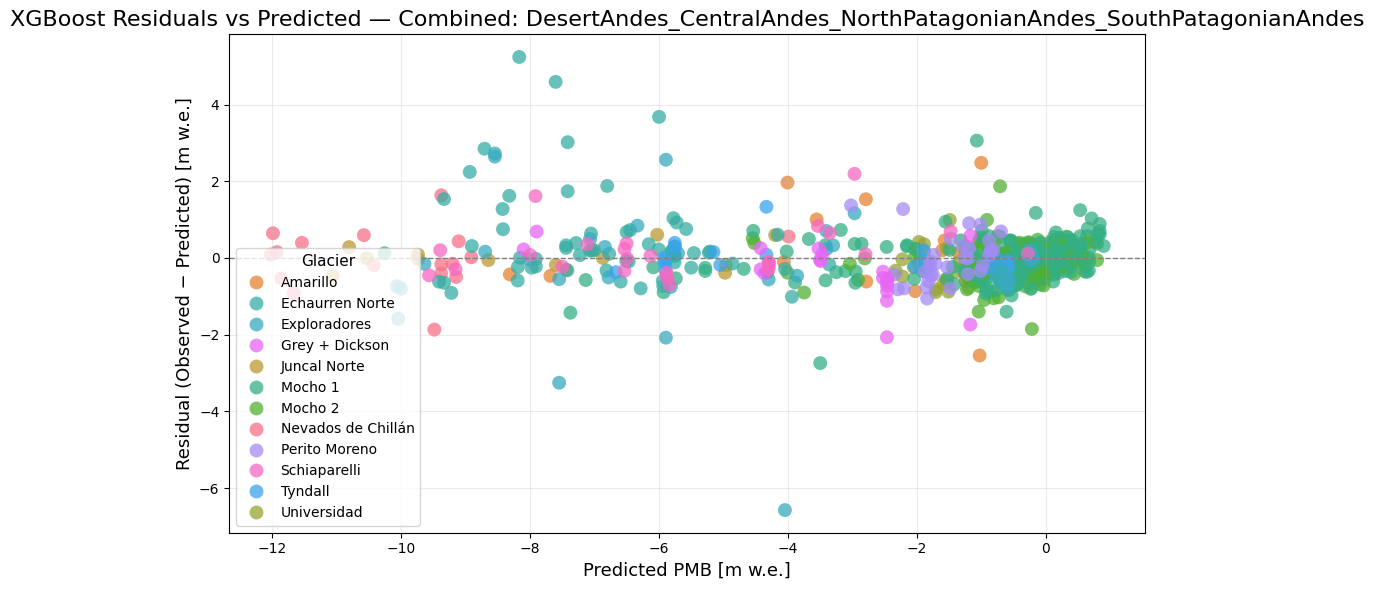

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP/residual_box_combined_DesertAndes_CentralAndes_NorthPatagonianAndes_SouthPatagonianAndes_20250827_103557.png


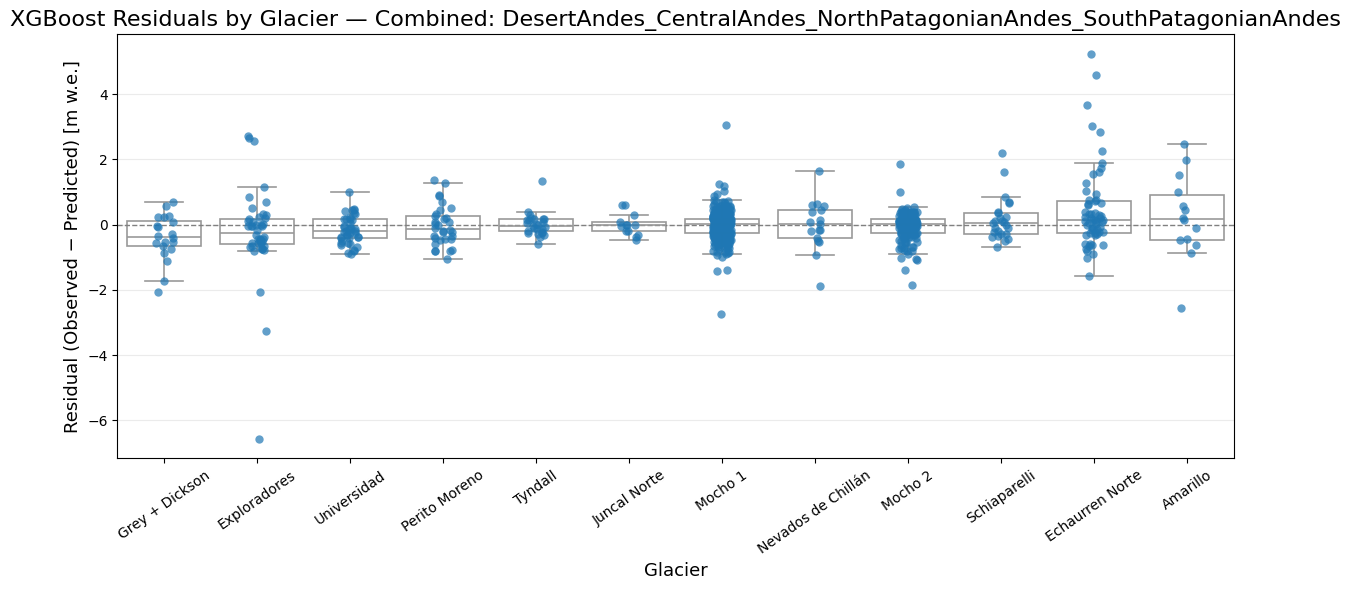

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP/relres_hist_combined_DesertAndes_CentralAndes_NorthPatagonianAndes_SouthPatagonianAndes_20250827_103557.png


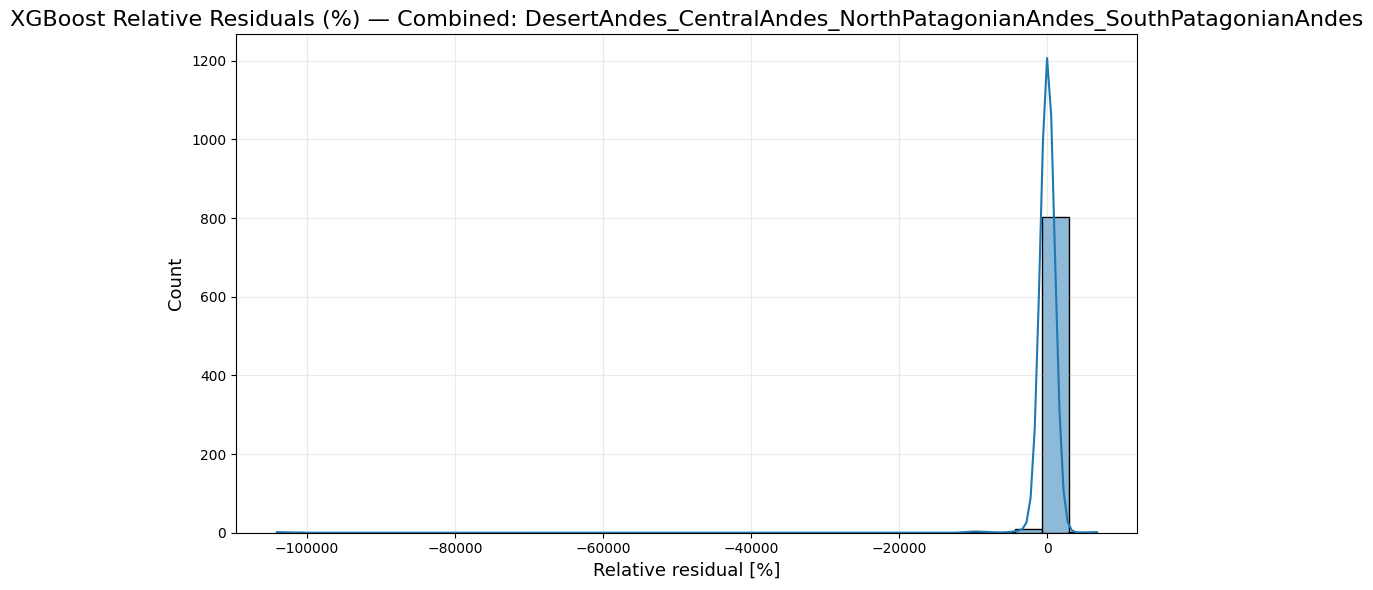

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP/relres_box_combined_DesertAndes_CentralAndes_NorthPatagonianAndes_SouthPatagonianAndes_20250827_103557.png


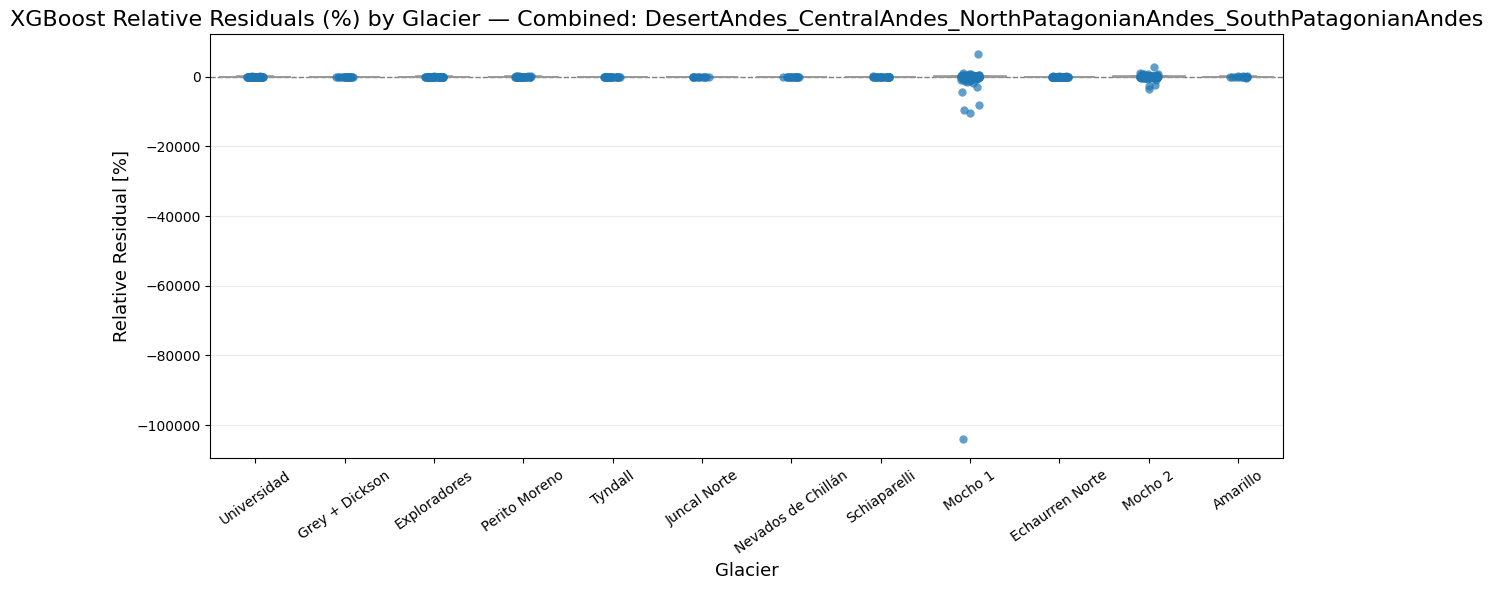

✓ Summary (combined) saved to: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/DA_CA_NP_SP/summary_relres_by_glacier_combined_DesertAndes_CentralAndes_NorthPatagonianAndes_SouthPatagonianAndes_20250827_103557.csv
✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP/res_vs_pred_DesertAndes_20250827_103557.png


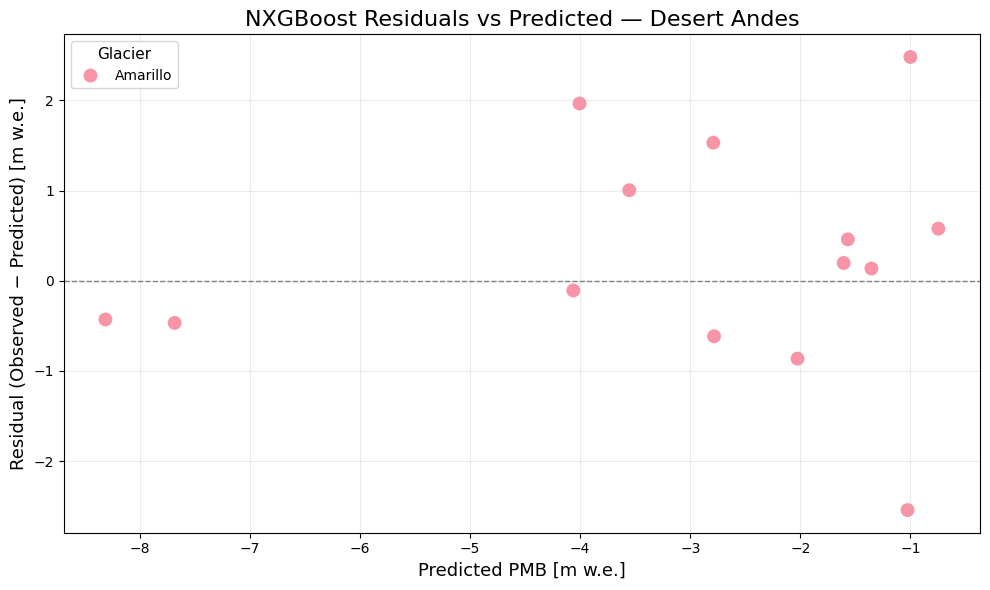

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP/residual_box_DesertAndes_20250827_103557.png


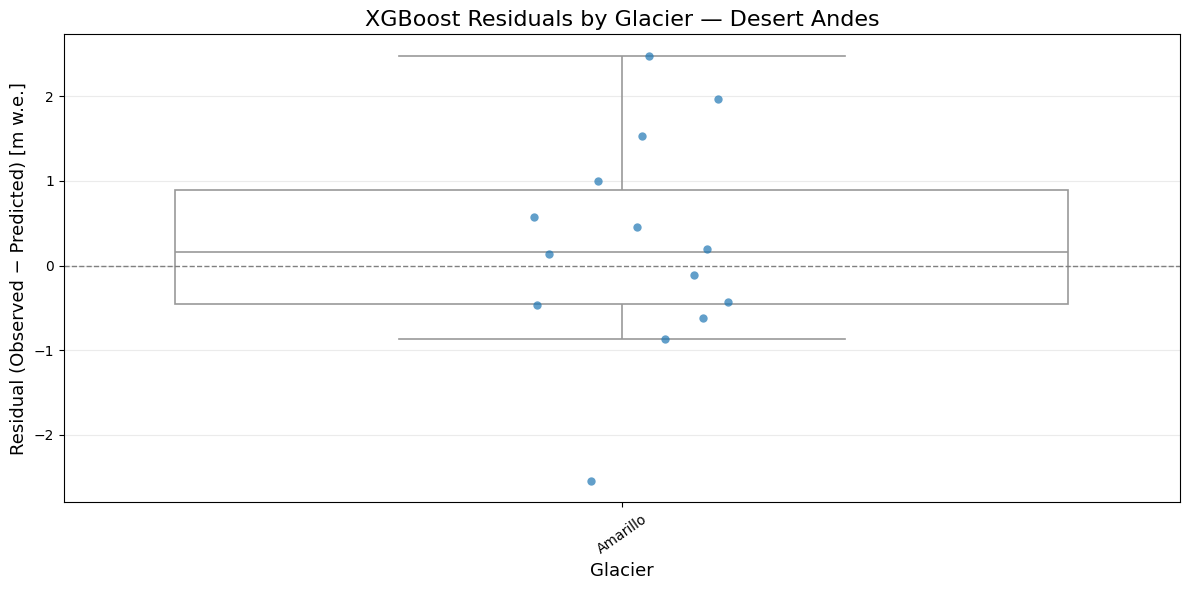

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP/relres_hist_DesertAndes_20250827_103557.png


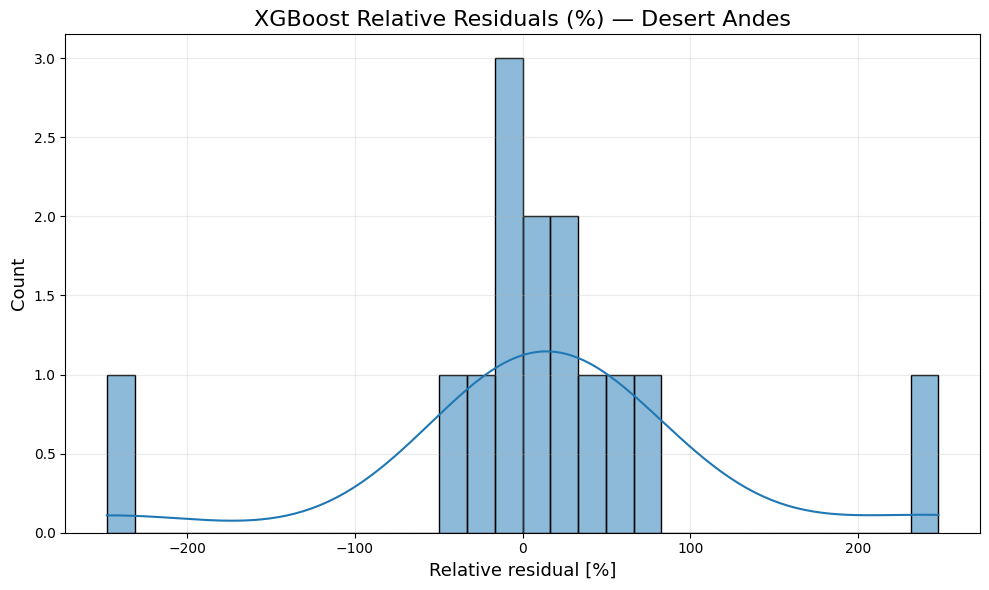

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP/relres_box_DesertAndes_20250827_103557.png


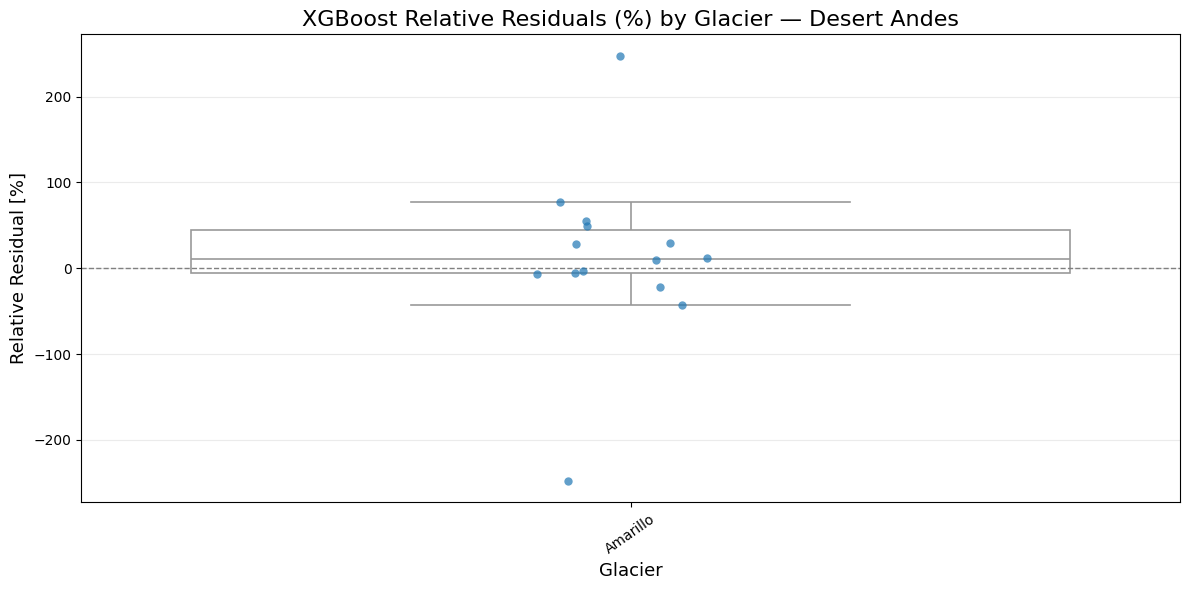

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP/res_vs_pred_CentralAndes_20250827_103557.png


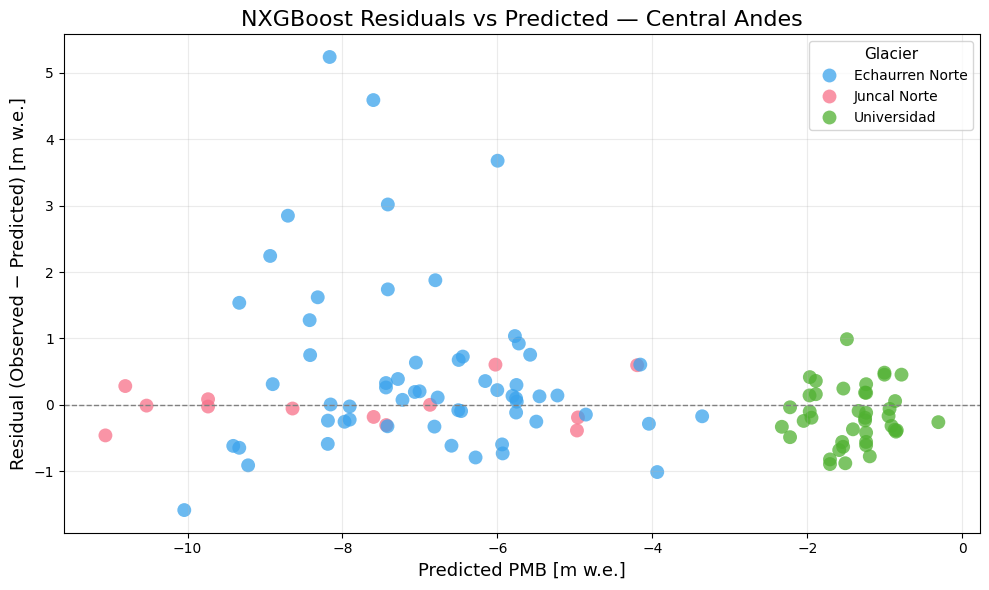

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP/residual_box_CentralAndes_20250827_103557.png


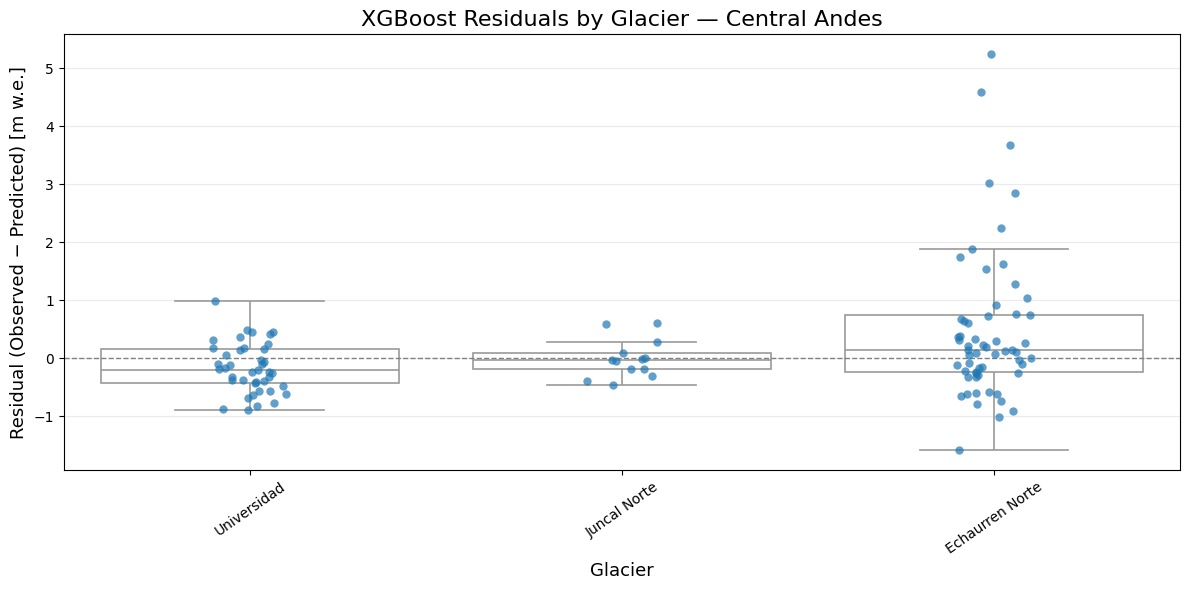

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP/relres_hist_CentralAndes_20250827_103557.png


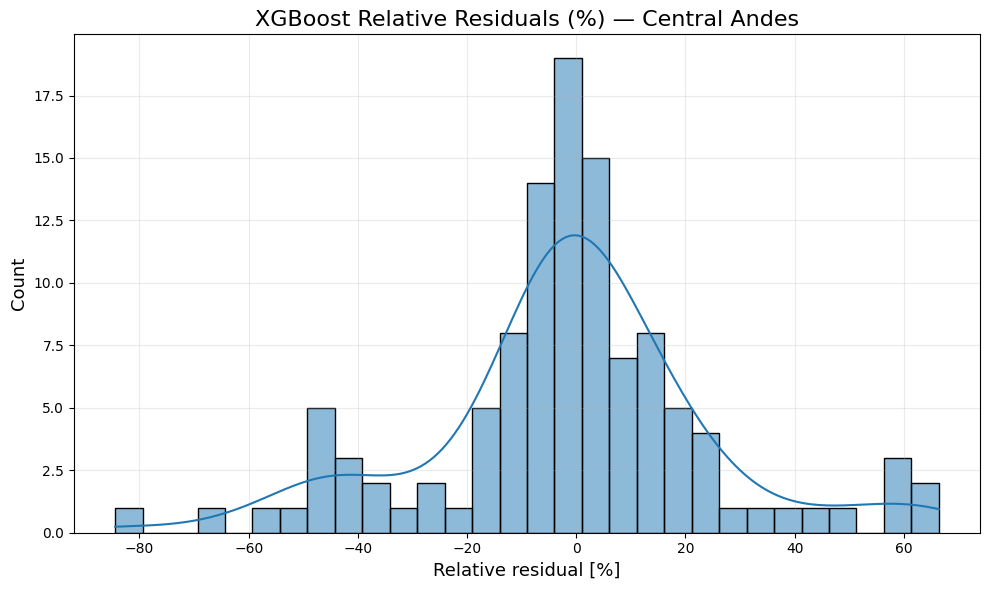

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP/relres_box_CentralAndes_20250827_103557.png


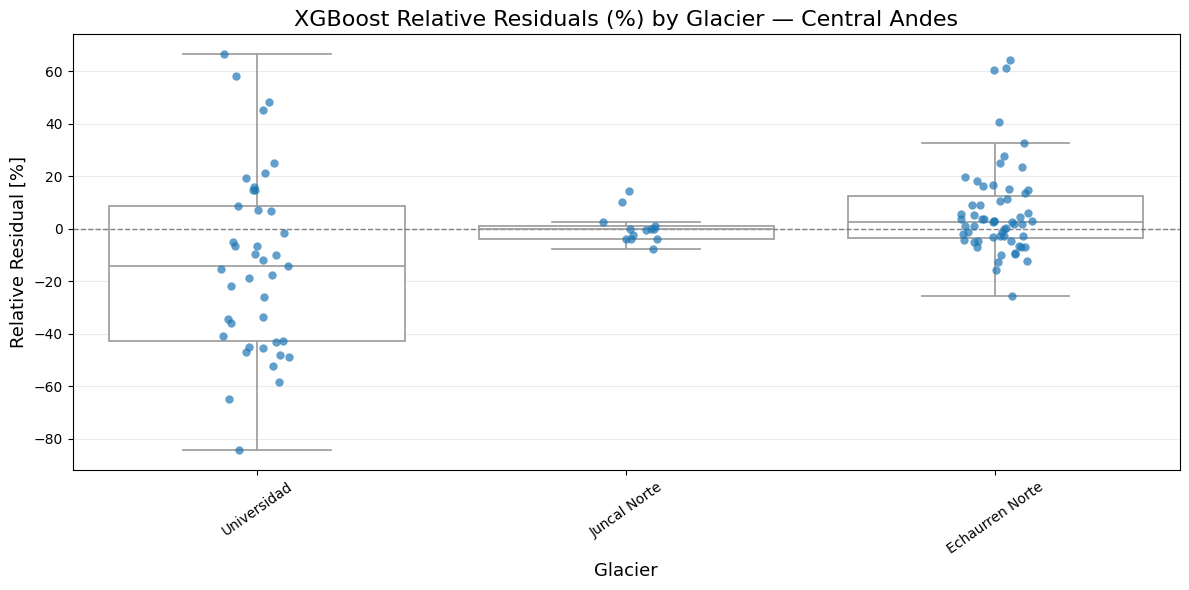

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP/res_vs_pred_NorthPatagonianAndes_20250827_103557.png


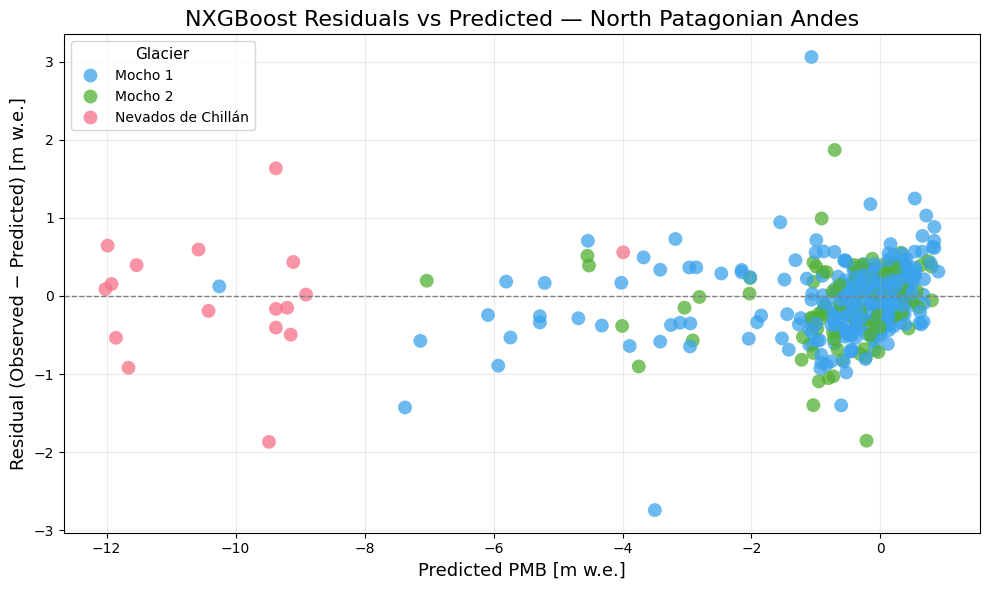

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP/residual_box_NorthPatagonianAndes_20250827_103557.png


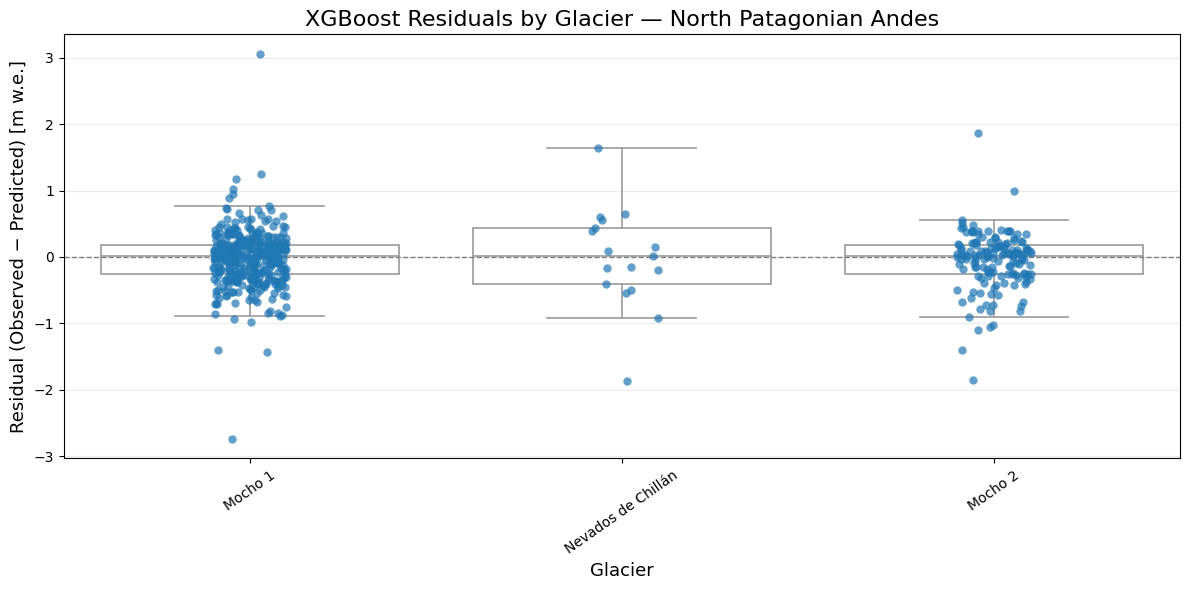

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP/relres_hist_NorthPatagonianAndes_20250827_103557.png


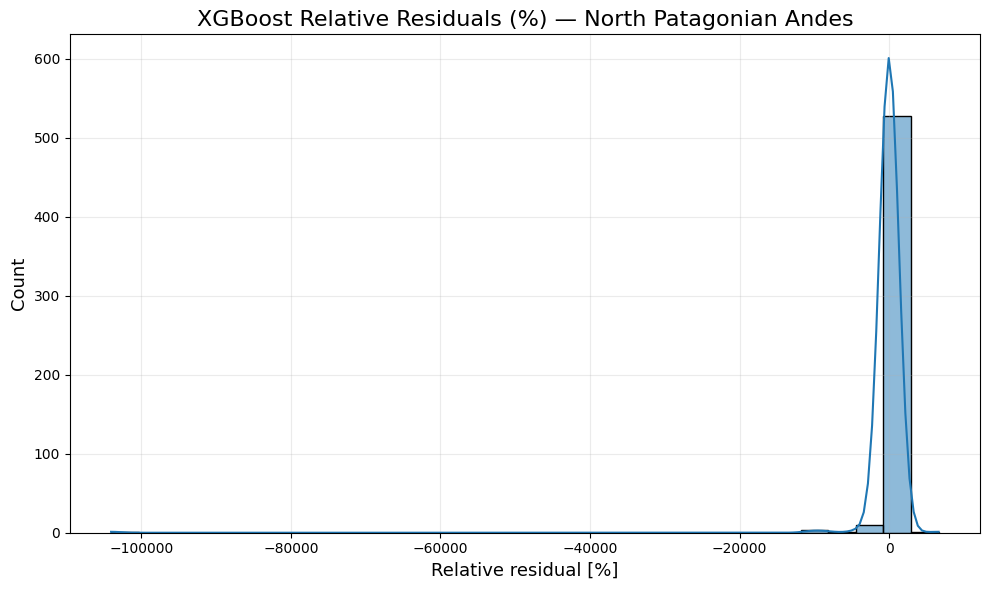

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP/relres_box_NorthPatagonianAndes_20250827_103557.png


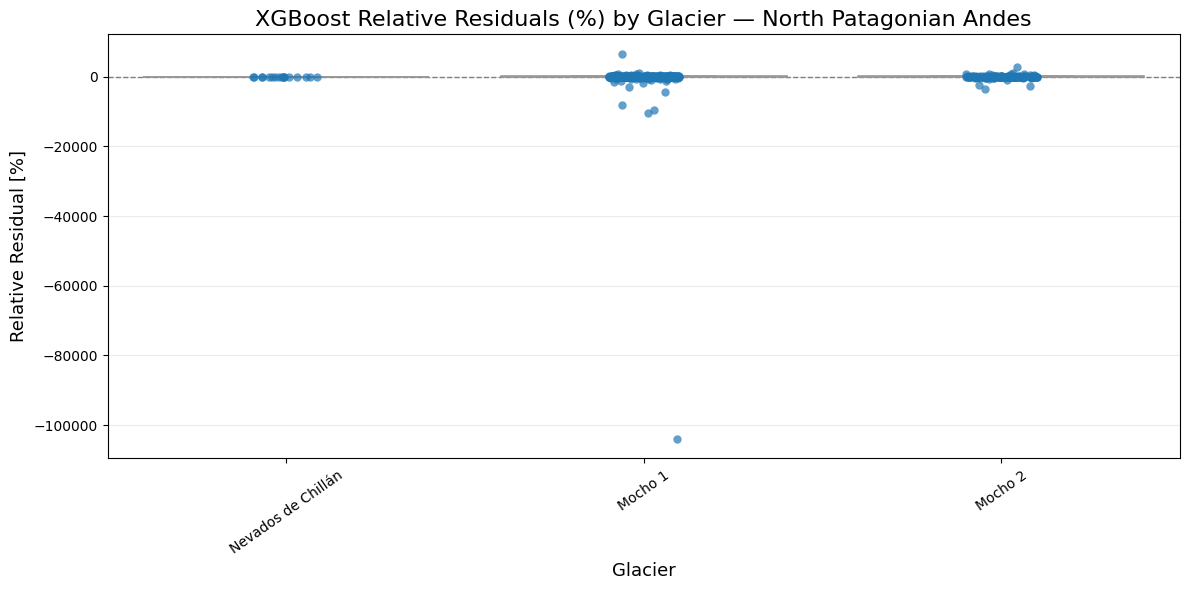

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP/res_vs_pred_SouthPatagonianAndes_20250827_103557.png


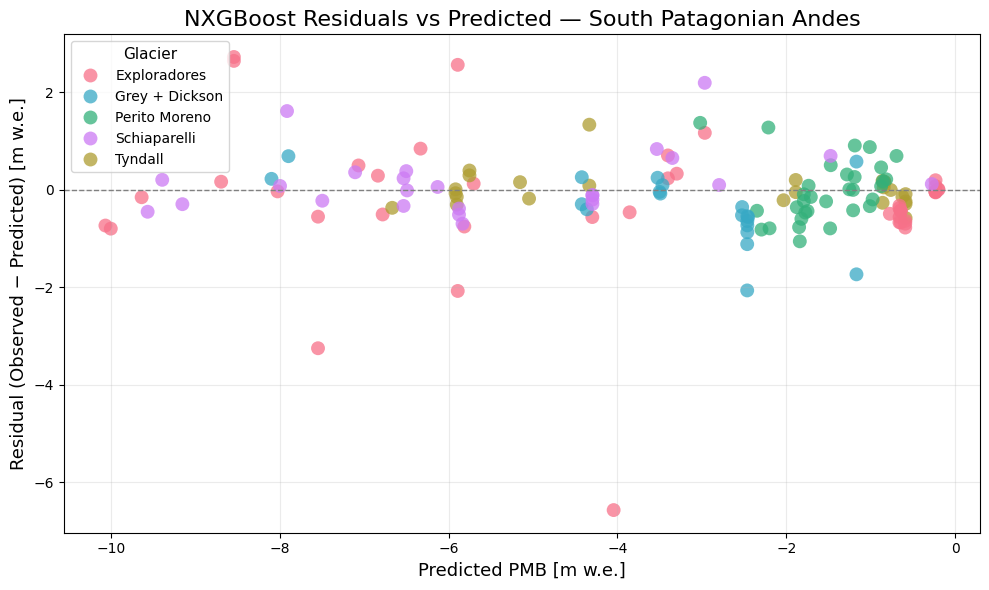

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP/residual_box_SouthPatagonianAndes_20250827_103557.png


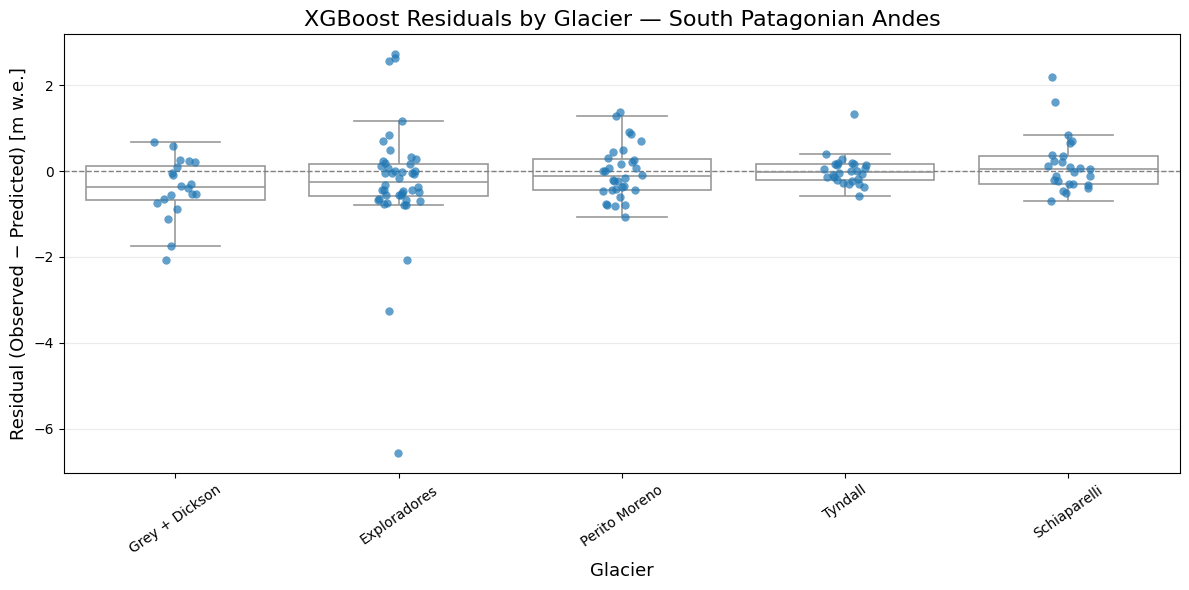

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP/relres_hist_SouthPatagonianAndes_20250827_103557.png


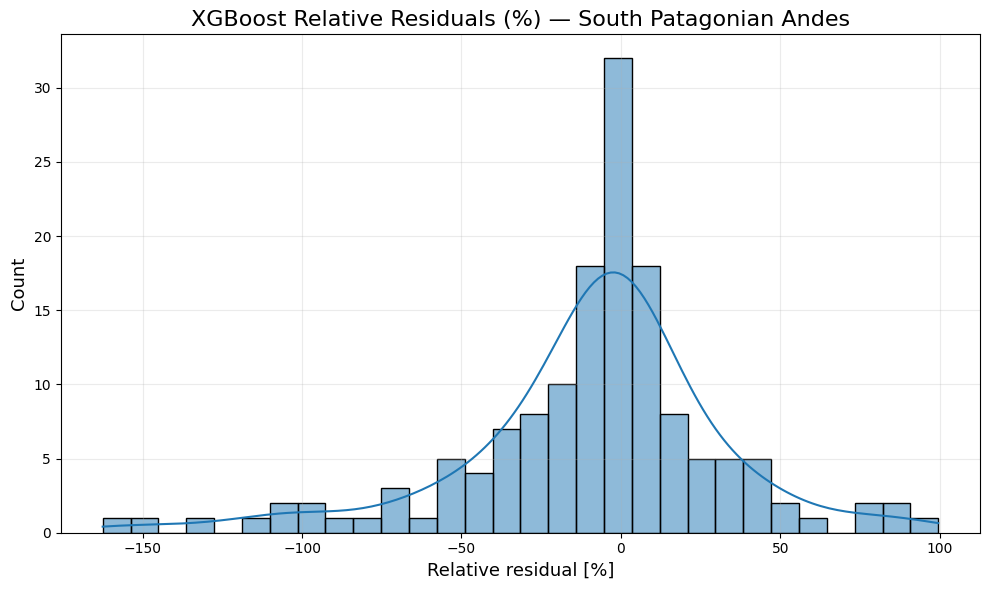

✓ Saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/DA_CA_NP_SP/relres_box_SouthPatagonianAndes_20250827_103557.png


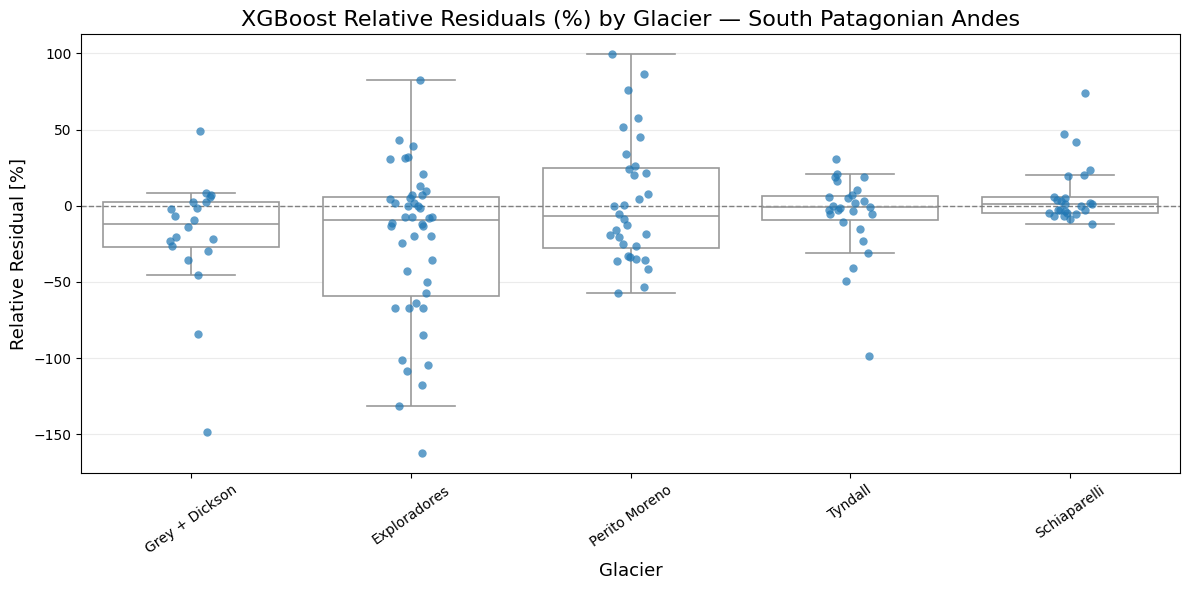

✓ Per-region glacier summaries saved to: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/DA_CA_NP_SP/summary_relres_by_glacier_per_region_DesertAndes_CentralAndes_NorthPatagonianAndes_SouthPatagonianAndes_20250827_103557.csv


In [20]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Core imports for data handling and plotting
# Importaciones básicas para manejo de datos y gráficos

 
# Utils
# Utilidades
 
def ensure_glacier_name(df, rgi_to_name=None, rgi_col='RGIId', out_col='GlacierName'):
    # Map RGIId -> readable glacier name; create/update 'GlacierName'
    # Mapear RGIId -> nombre legible de glaciar; crear/actualizar 'GlacierName'
    """Crea/actualiza la columna GlacierName mapeando RGIId -> nombre legible."""
    out = df.copy()
    rgi_to_name = rgi_to_name or {}
    if rgi_col not in out.columns:
        raise KeyError(f"Missing column '{rgi_col}' in dataframe.")
    out[out_col] = out[rgi_col].map(rgi_to_name).fillna(out[rgi_col])
    return out

def _finite_mask(*arrays):
    # Build a boolean mask that is True only where all arrays are finite
    # Construir una máscara booleana True solo donde todos los arreglos son finitos
    masks = [(np.isfinite(np.asarray(a))) for a in arrays]
    m = masks[0]
    for mm in masks[1:]:
        m = m & mm
    return m

 
# Residual columns (ID-level)
# Columnas de residuales (nivel ID)
 
def add_residual_columns(df, target_col='target', pred_col='pred', rel_den='pred'):
    # Add residual and % relative residual using |pred| or |target| as denominator
    # Agregar residual y residual relativo % usando |pred| o |target| como denominador
    """
    Agrega:
      - residual = target - pred
      - rel_residual_pct = 100 * residual / |denominador|
    rel_den en {'pred','target'} define el denominador relativo.
    """
    out = df.copy()
    if target_col not in out.columns or pred_col not in out.columns:
        raise KeyError(f"'{target_col}' or '{pred_col}' not in dataframe.")
    out['residual'] = out[target_col] - out[pred_col]

    eps = 1e-9
    if rel_den == 'pred':
        base = out[pred_col].to_numpy(dtype=float)
    elif rel_den == 'target':
        base = out[target_col].to_numpy(dtype=float)
    else:
        raise ValueError("rel_den must be 'pred' or 'target'")

    denom = np.where(np.abs(base) > eps, np.abs(base), np.nan)
    out['rel_residual_pct'] = 100.0 * (out['residual'].to_numpy(dtype=float) / denom)
    return out

 
# Scatter: residuals vs predicted (ID-level)
# Dispersión: residuales vs predicho (nivel ID)
 
def plot_residuals_vs_pred(df_res, hue_col='GlacierName',
                           title='Residuals vs Predicted (ID-level)',
                           savepath=None):
    # Validate required cols; filter non-finite; draw scatter with glacier hue
    # Validar columnas; filtrar no finitos; graficar dispersión con color por glaciar
    df = df_res.copy()
    if 'pred' not in df.columns or 'residual' not in df.columns:
        raise KeyError("df_res must contain 'pred' and 'residual'.")

    # Mask invalid rows (NaN/Inf) for stable plotting
    # Enmascarar filas inválidas (NaN/Inf) para graficar estable
    m = _finite_mask(df['pred'].to_numpy(), df['residual'].to_numpy())
    dropped = (~m).sum()
    if dropped:
        print(f"⚠️ Dropping {dropped} rows with NaN/Inf for residual-vs-pred plot.")
    df = df.loc[m].copy()
    if df.empty:
        raise ValueError("No valid rows to plot (residual-vs-pred).")

    # Build color palette per glacier group
    # Construir paleta de colores por grupo de glaciar
    n_groups = df[hue_col].nunique() if hue_col in df.columns else 1
    palette = sns.color_palette("husl", max(n_groups, 1))

    fig, ax = plt.subplots(figsize=(10, 6))
    if hue_col in df.columns:
        sns.scatterplot(data=df, x='pred', y='residual', hue=hue_col,
                        palette=palette, s=100, alpha=0.75, ax=ax, edgecolor='none')
    else:
        sns.scatterplot(data=df, x='pred', y='residual',
                        s=100, alpha=0.75, ax=ax, edgecolor='none')

    # Zero-line and labels
    # Línea cero y etiquetas
    ax.axhline(0, color='grey', linestyle='--', linewidth=1)
    ax.set_xlabel('Predicted PMB [m w.e.]', fontsize=13)
    ax.set_ylabel('Residual (Observed − Predicted) [m w.e.]', fontsize=13)
    ax.set_title(title, fontsize=16)
    ax.grid(True, alpha=0.25)

    # Sort legend alphabetically for readability
    # Ordenar leyenda alfabéticamente para legibilidad
    if hue_col in df.columns:
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            pairs = sorted(zip(labels, handles), key=lambda t: t[0])
            labels_sorted, handles_sorted = zip(*pairs)
            ax.legend(handles_sorted, labels_sorted, title='Glacier',
                      fontsize=10, title_fontsize=11, loc='best', frameon=True)

    # Save (optional) and show
    # Guardar (opcional) y mostrar
    plt.tight_layout()
    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=300)
        print(f"✓ Saved: {savepath}")
    plt.show()
    return fig, ax

 
# Boxplot of residuals by glacier (ID-level)
# Boxplot de residuales por glaciar (nivel ID)
 
def plot_residuals_by_glacier_box(df_res, hue_col='GlacierName',
                                  title='Residuals by Glacier (ID-level)',
                                  savepath=None):
    # Validate inputs; keep finite; order glaciers by median residual
    # Validar entradas; mantener finitos; ordenar glaciares por mediana del residual
    df = df_res.copy()
    if 'residual' not in df.columns or hue_col not in df.columns:
        raise KeyError("df_res must contain 'residual' and the hue column.")
    m = np.isfinite(df['residual'].to_numpy())
    df = df.loc[m].copy()
    if df.empty:
        raise ValueError("No valid rows to plot (residual boxplot).")

    # Ordering to highlight differences/outliers
    # Orden para resaltar diferencias/outliers
    order = (df.groupby(hue_col)['residual']
               .median()
               .sort_values()
               .index
               .tolist())

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=df, x=hue_col, y='residual', order=order,
                color='white', fliersize=0, linewidth=1.2, ax=ax)
    sns.stripplot(data=df, x=hue_col, y='residual', order=order,
                  alpha=0.7, size=6, ax=ax, color='tab:blue')

    # Reference line and styling
    # Línea de referencia y estilo
    ax.axhline(0, color='grey', linestyle='--', linewidth=1)
    ax.set_xlabel('Glacier', fontsize=13)
    ax.set_ylabel('Residual (Observed − Predicted) [m w.e.]', fontsize=13)
    ax.set_title(title, fontsize=16)
    ax.tick_params(axis='x', rotation=35)
    ax.grid(True, axis='y', alpha=0.25)
    plt.tight_layout()
    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=300)
        print(f"✓ Saved: {savepath}")
    plt.show()
    return fig, ax

 
# Histogram of relative residuals (ID-level)
# Histograma de residuales relativos (nivel ID)
 
def plot_relative_residual_hist(df_res, title='Relative residuals (% of |Base|)',
                                savepath=None, bins=30):
    # Validate column; clean inf/nan; plot distribution with KDE
    # Validar columna; limpiar inf/nan; graficar distribución con KDE
    if 'rel_residual_pct' not in df_res.columns:
        raise KeyError("df_res must contain 'rel_residual_pct'.")
    vals = (df_res['rel_residual_pct']
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
            .to_numpy(dtype=float))
    if vals.size == 0:
        raise ValueError("No valid values for relative residual histogram.")

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.histplot(vals, bins=bins, kde=True, ax=ax)
    ax.set_xlabel('Relative residual [%]', fontsize=13)
    ax.set_ylabel('Count', fontsize=13)
    ax.set_title(title, fontsize=16)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=300)
        print(f"✓ Saved: {savepath}")
    plt.show()
    return fig, ax

 
# Boxplot of relative residuals by glacier (ID-level)
# Boxplot de residuales relativos por glaciar (nivel ID)
 
def plot_relative_residual_box(df_res, hue_col='GlacierName',
                               title='Relative Residuals (%) by Glacier (ID-level)',
                               savepath=None):
    # Validate inputs; keep finite; order by median relative residual
    # Validar entradas; mantener finitos; ordenar por mediana del residual relativo
    df = df_res.copy()
    if 'rel_residual_pct' not in df.columns or hue_col not in df.columns:
        raise KeyError("df_res must contain 'rel_residual_pct' and the hue column.")
    m = np.isfinite(df['rel_residual_pct'].to_numpy())
    df = df.loc[m].copy()
    if df.empty:
        raise ValueError("No valid rows to plot (relative residual boxplot).")

    order = (df.groupby(hue_col)['rel_residual_pct']
               .median()
               .sort_values()
               .index
               .tolist())

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=df, x=hue_col, y='rel_residual_pct', order=order,
                color='white', fliersize=0, linewidth=1.2, ax=ax)
    sns.stripplot(data=df, x=hue_col, y='rel_residual_pct', order=order,
                  alpha=0.7, size=6, ax=ax, color='tab:blue')

    # Labels, styling, and grid
    # Etiquetas, estilo y cuadrícula
    ax.axhline(0, color='grey', linestyle='--', linewidth=1)
    ax.set_xlabel('Glacier', fontsize=13)
    ax.set_ylabel('Relative Residual [%]', fontsize=13)
    ax.set_title(title, fontsize=16)
    ax.tick_params(axis='x', rotation=35)
    ax.grid(True, axis='y', alpha=0.25)
    plt.tight_layout()
    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=300)
        print(f"✓ Saved: {savepath}")
    plt.show()
    return fig, ax

 
# Statistical summary by glacier (ID-level)
# Resumen estadístico por glaciar (nivel ID)
 
def summarize_relative_residuals(df_res, hue_col='GlacierName'):
    # Group by glacier and compute count/mean/std/min/median/max; round for neatness
    # Agrupar por glaciar y calcular conteo/media/std/min/mediana/máx; redondear por prolijidad
    if 'rel_residual_pct' not in df_res.columns or hue_col not in df_res.columns:
        raise KeyError("df_res must contain 'rel_residual_pct' and the hue column.")
    df = df_res[['rel_residual_pct', hue_col]].copy()
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['rel_residual_pct'])
    summary = (df.groupby(hue_col)['rel_residual_pct']
                 .agg(count='count', mean='mean', std='std', min='min', median='median', max='max')
                 .reset_index())
    # Round numeric columns
    # Redondear columnas numéricas
    for c in ['mean','std','min','median','max']:
        summary[c] = summary[c].round(2)
    return summary

 
# Example usage (Combined + Per region)
# Ejemplo de uso (Combinado + Por región)
 

# --- COMBINED ---
# Ensure glacier names then compute residuals (relative to |pred| by default)
# Asegurar nombres de glaciar y luego calcular residuales (relativos a |pred| por defecto)
res_comb = ensure_glacier_name(grouped_sel, rgi_to_name=rgi_to_name)
res_comb = add_residual_columns(res_comb, target_col='target', pred_col='pred', rel_den='pred')

# Combined plots (scatter, boxplots, hist)
# Gráficos combinados (dispersión, boxplots, histograma)
plot_residuals_vs_pred(
    res_comb,
    title=f'XGBoost Residuals vs Predicted — Combined: {regions_tag}',
    savepath=os.path.join(fig_path, f'res_vs_pred_combined_{regions_tag}_{ts}.png')
)
plot_residuals_by_glacier_box(
    res_comb,
    title=f'XGBoost Residuals by Glacier — Combined: {regions_tag}',
    savepath=os.path.join(fig_path, f'residual_box_combined_{regions_tag}_{ts}.png')
)
plot_relative_residual_hist(
    res_comb,
    title=f'XGBoost Relative Residuals (%) — Combined: {regions_tag}',
    savepath=os.path.join(fig_path, f'relres_hist_combined_{regions_tag}_{ts}.png')
)
plot_relative_residual_box(
    res_comb,
    title=f'XGBoost Relative Residuals (%) by Glacier — Combined: {regions_tag}',
    savepath=os.path.join(fig_path, f'relres_box_combined_{regions_tag}_{ts}.png')
)

# Save combined summary CSV by glacier
# Guardar CSV de resumen combinado por glaciar
summary_comb = summarize_relative_residuals(res_comb)
summary_comb_path = os.path.join(out_dir, f'summary_relres_by_glacier_combined_{regions_tag}_{ts}.csv')
summary_comb.to_csv(summary_comb_path, index=False)
print(f"✓ Summary (combined) saved to: {summary_comb_path}")

# --- PER REGION ---
# Loop through regions to plot and export summaries
# Recorrer regiones para graficar y exportar resúmenes
all_region_summaries = []
for reg, grouped_r in per_region_agg_outputs:
    # Per-region glacier names and residuals
    # Nombres de glaciar y residuales por región
    res_r = ensure_glacier_name(grouped_r, rgi_to_name=rgi_to_name)
    res_r = add_residual_columns(res_r, target_col='target', pred_col='pred', rel_den='pred')

    # Per-region plots
    # Gráficos por región
    plot_residuals_vs_pred(
        res_r,
        title=f'NXGBoost Residuals vs Predicted — {reg}',
        savepath=os.path.join(fig_path, f'res_vs_pred_{slugify(reg)}_{ts}.png')
    )
    plot_residuals_by_glacier_box(
        res_r,
        title=f'XGBoost Residuals by Glacier — {reg}',
        savepath=os.path.join(fig_path, f'residual_box_{slugify(reg)}_{ts}.png')
    )
    plot_relative_residual_hist(
        res_r,
        title=f'XGBoost Relative Residuals (%) — {reg}',
        savepath=os.path.join(fig_path, f'relres_hist_{slugify(reg)}_{ts}.png')
    )
    plot_relative_residual_box(
        res_r,
        title=f'XGBoost Relative Residuals (%) by Glacier — {reg}',
        savepath=os.path.join(fig_path, f'relres_box_{slugify(reg)}_{ts}.png')
    )

    # Build per-region summary table and collect
    # Construir tabla resumen por región y acumular
    summary_r = summarize_relative_residuals(res_r)
    summary_r.insert(0, 'region', reg)
    all_region_summaries.append(summary_r)

# Concatenate and save per-region summaries
# Concatenar y guardar resúmenes por región
if all_region_summaries:
    df_summary_regions = pd.concat(all_region_summaries, ignore_index=True)
    path_summary_regions = os.path.join(out_dir, f'summary_relres_by_glacier_per_region_{regions_tag}_{ts}.csv')
    df_summary_regions.to_csv(path_summary_regions, index=False)
    print(f"✓ Per-region glacier summaries saved to: {path_summary_regions}")


✓ Heatmap saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/CA_NP/corr_features_pearson_DesertAndes_CentralAndes_NorthPatagonianAndes_20250827_105003.png


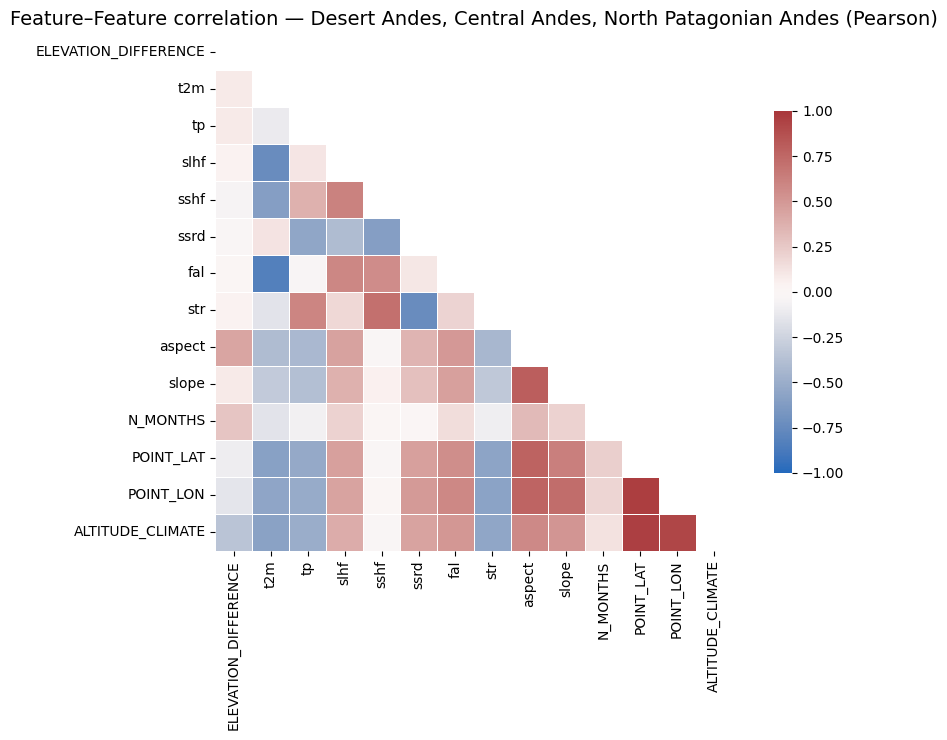

✓ Heatmap saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/CA_NP/corr_features_spearman_DesertAndes_CentralAndes_NorthPatagonianAndes_20250827_105003.png


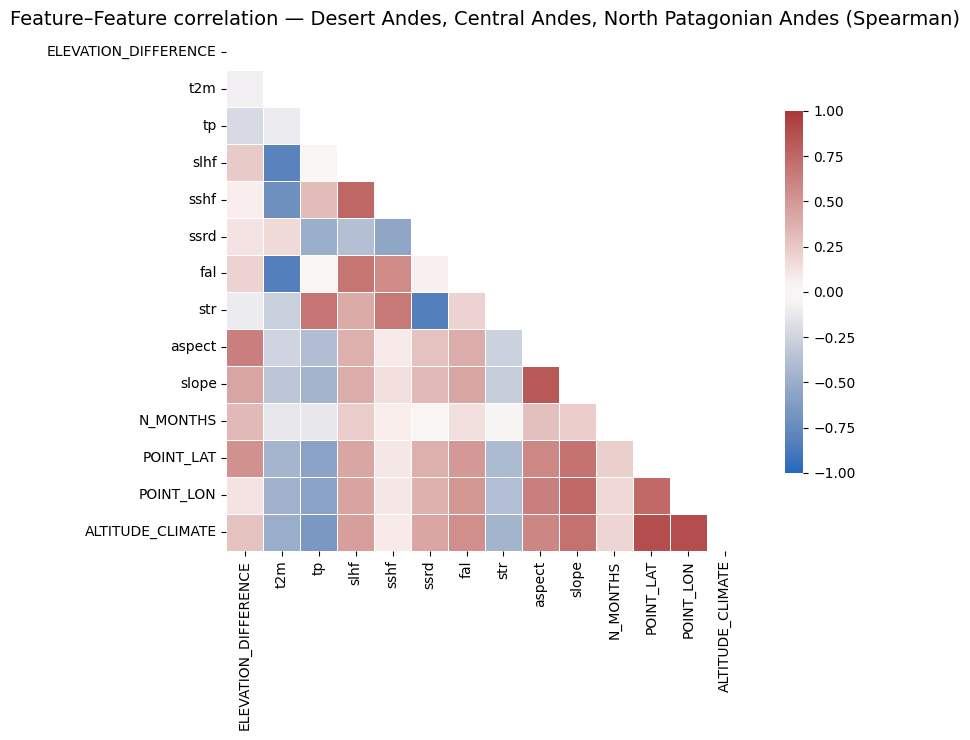

✓ Barplot saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/CA_NP/corr_with_TARGET_pearson_top_DesertAndes_CentralAndes_NorthPatagonianAndes_20250827_105003.png


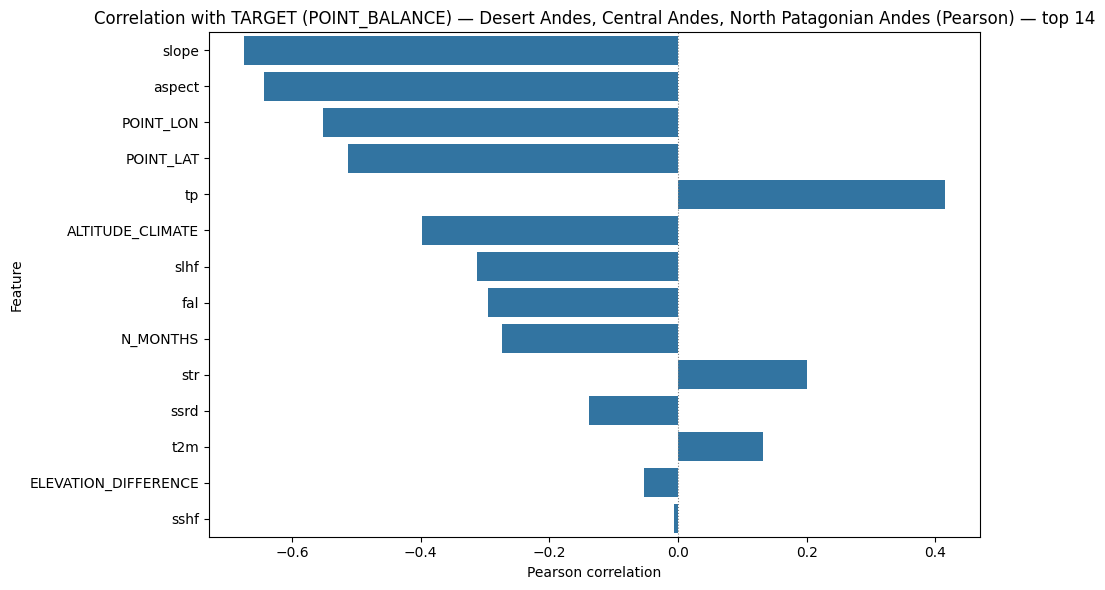

✓ Barplot saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/CA_NP/corr_with_TARGET_spearman_top_DesertAndes_CentralAndes_NorthPatagonianAndes_20250827_105003.png


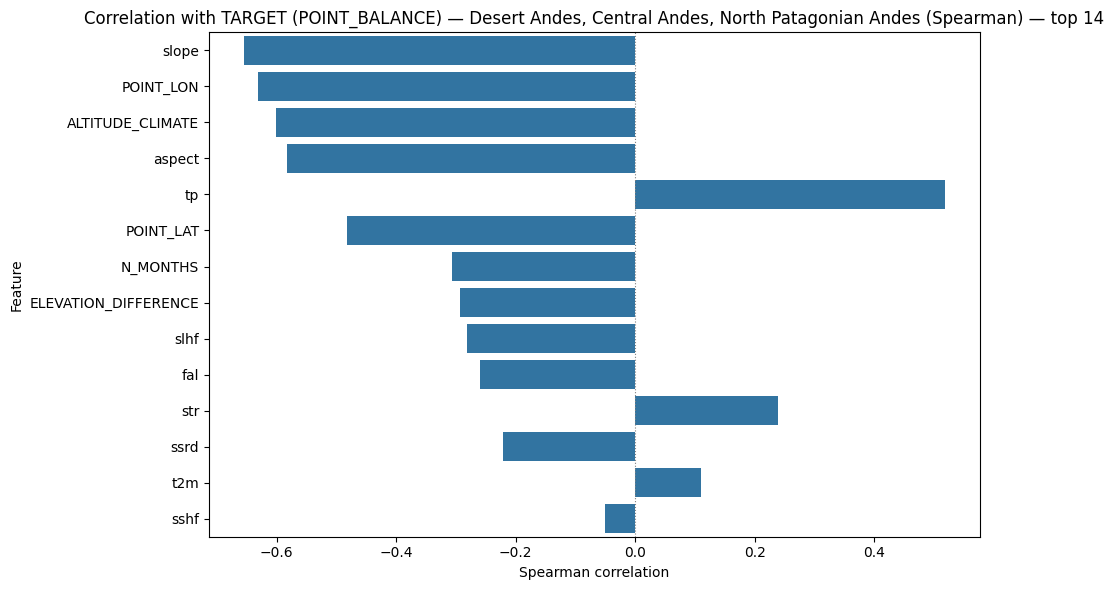

✓ Barplot saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/CA_NP/corr_with_PRED_pearson_top_DesertAndes_CentralAndes_NorthPatagonianAndes_20250827_105003.png


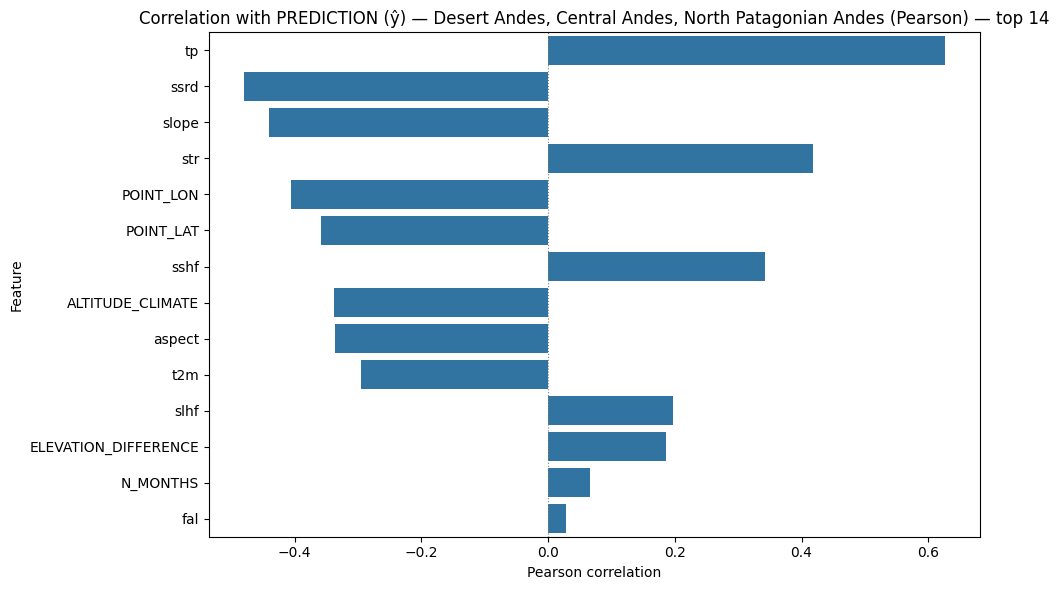

✓ Barplot saved: /mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/CA_NP/corr_with_PRED_spearman_top_DesertAndes_CentralAndes_NorthPatagonianAndes_20250827_105003.png


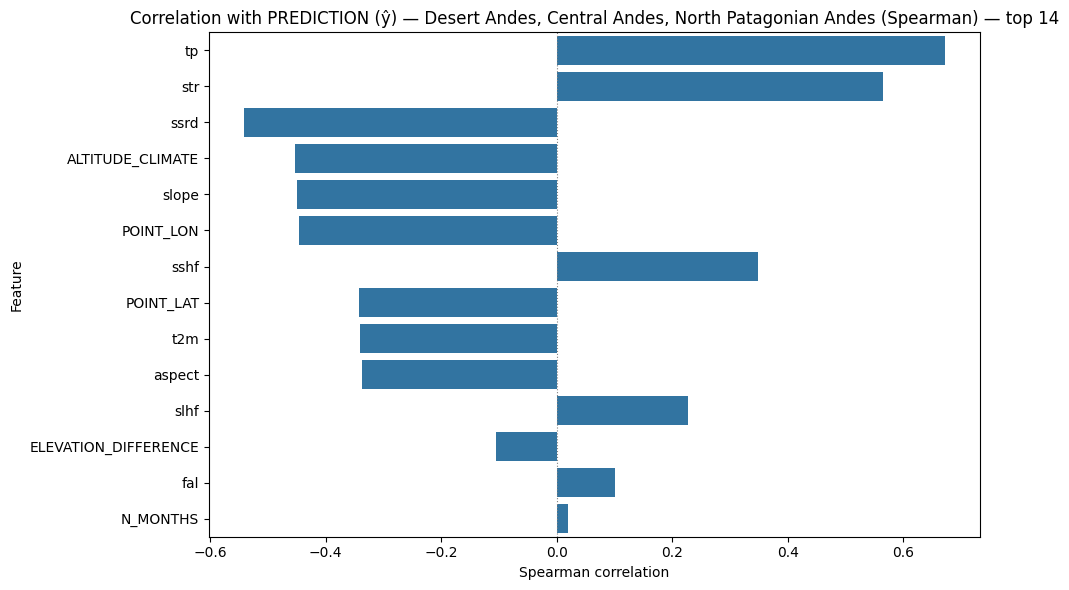

✓ Correlation analysis finished (descriptor-only X; target = POINT_BALANCE).


In [21]:
import os
from datetime import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import load

# Config/util: unwrap CV wrappers to the fitted estimator
# Config/util: destapa envoltorios de CV para obtener el estimador entrenado
def ensure_best_estimator(obj):
    return getattr(obj, 'best_estimator_', obj)

# Build a test slice by explicit regions (expects 'region' + all_columns present)
# Construye un subconjunto de test por regiones explícitas (requiere 'region' + all_columns)
def make_test_from_regions(data, regions):
    if isinstance(regions, str):
        regions = [regions]
    wanted = {r.strip() for r in regions}
    df_sel = data[data['region'].astype(str).str.strip().isin(wanted)].copy()
    if df_sel.empty:
        raise ValueError(f"No rows found for selected regions: {sorted(wanted)}")
    X_sel = df_sel[all_columns]
    y_sel = df_sel['POINT_BALANCE'].values
    return df_sel, X_sel, y_sel

# Triangular heatmap of feature–feature correlations
# Mapa de calor triangular de correlaciones entre descriptores
def plot_corr_heatmap(df_num, method='pearson', vmax=1.0, vmin=-1.0,
                      title='Feature correlation', savepath=None):
    corr = df_num.corr(method=method)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    n = len(df_num.columns)
    fig_w = min(max(10, 0.4 * n), 24)
    fig_h = fig_w * 0.75

    plt.figure(figsize=(fig_w, fig_h))
    sns.heatmap(corr, mask=mask, cmap='vlag', center=0, vmin=vmin, vmax=vmax,
                square=True, linewidths=.5, cbar_kws={'shrink': .7})
    plt.title(f'{title} ({method.capitalize()})', fontsize=14)
    plt.tight_layout()
    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=300)
        print(f'✓ Heatmap saved: {savepath}')
    plt.show()
    return corr

# Bar chart: correlation of each feature with a reference vector (y or ŷ)
# Barras: correlación de cada descriptor con un vector de referencia (y o ŷ)
def bar_corr_with_vector(df_num, vec, method='pearson', top_k=30,
                         title='Correlation with vector', savepath=None, xlabel=None):
    y_s = pd.Series(vec, index=df_num.index)
    vals = {}
    for col in df_num.columns:
        try:
            vals[col] = df_num[col].corr(y_s, method=method)
        except Exception:
            vals[col] = np.nan
    s = pd.Series(vals).dropna().sort_values(key=lambda v: v.abs(), ascending=False)
    if top_k is not None:
        s = s.head(top_k)

    plt.figure(figsize=(10, max(6, 0.35 * len(s))))
    sns.barplot(x=s.values, y=s.index, orient='h')
    plt.axvline(0, color='grey', linestyle=':', linewidth=0.8)
    plt.xlabel(xlabel or f'{method.capitalize()} correlation')
    plt.ylabel('Feature')
    plt.title(f'{title} ({method.capitalize()}) — top {len(s)}')
    plt.tight_layout()
    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=300)
        print(f'✓ Barplot saved: {savepath}')
    plt.show()
    return s

# Paths, model, and region selection
# Rutas, modelo y selección de regiones
obj = load('/mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/entrenamientos/model_xgb_CA_NP.pkl')
xgb = ensure_best_estimator(obj)

out_dir  = '/mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/CA_NP'
fig_path = '/mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/output/evaluations/figs/CA_NP'
os.makedirs(out_dir, exist_ok=True)
os.makedirs(fig_path, exist_ok=True)

# Pick regions for analysis (ensure your model supports them)
# Elige regiones a analizar (asegúrate que el modelo las soporta)
analyze_regions = ["Desert Andes", "Central Andes", "North Patagonian Andes"]
df_sel, X_sel_w_target, y_sel = make_test_from_regions(data, analyze_regions)

# Prepare descriptor matrix X (drop target/IDs/time columns in one shot)
# Preparar matriz de descriptores X (quitar target/IDs/tiempo de una vez)
X_desc = X_sel_w_target.drop(columns=['POINT_BALANCE', 'ID', 'YEAR', 'N_MONTH'], errors='ignore').copy()

# Keep only numeric (cast bool→int), remove constants, limit NaNs, and fill
# Mantener solo numéricas (bool→int), eliminar constantes, limitar NaNs y rellenar
bool_cols = X_desc.select_dtypes(include=['bool']).columns
if len(bool_cols):
    X_desc[bool_cols] = X_desc[bool_cols].astype(int)
num_cols = X_desc.select_dtypes(include=[np.number]).columns.tolist()
X_desc = X_desc[num_cols]

var = X_desc.var(numeric_only=True)
X_desc = X_desc[var[var > 0].index]

na_ratio = X_desc.isna().mean()
X_desc = X_desc[na_ratio[na_ratio < 0.2].index].fillna(method='ffill').fillna(method='bfill')

# Timestamp + compact tag for filenames
# Sello temporal + etiqueta compacta para nombres de archivo
ts  = datetime.now().strftime('%Y%m%d_%H%M%S')
tag = "_".join(s.replace(" ", "") for s in analyze_regions)

# (1) Feature–feature correlation heatmaps
# (1) Mapas de calor de correlación entre descriptores
heatmap_p_path = os.path.join(fig_path, f'corr_features_pearson_{tag}_{ts}.png')
corr_ff_p = plot_corr_heatmap(
    X_desc, method='pearson',
    title=f'Feature–Feature correlation — {", ".join(analyze_regions)}',
    savepath=heatmap_p_path
)

heatmap_s_path = os.path.join(fig_path, f'corr_features_spearman_{tag}_{ts}.png')
corr_ff_s = plot_corr_heatmap(
    X_desc, method='spearman',
    title=f'Feature–Feature correlation — {", ".join(analyze_regions)}',
    savepath=heatmap_s_path
)

# (2) Correlation of features with TARGET (y_sel = POINT_BALANCE)
# (2) Correlación de descriptores con el TARGET (y_sel = POINT_BALANCE)
bar_y_p_path = os.path.join(fig_path, f'corr_with_TARGET_pearson_top_{tag}_{ts}.png')
corr_fx_y_p = bar_corr_with_vector(
    X_desc, y_sel, method='pearson', top_k=30,
    title=f'Correlation with TARGET (POINT_BALANCE) — {", ".join(analyze_regions)}',
    savepath=bar_y_p_path, xlabel='Pearson correlation'
)

bar_y_s_path = os.path.join(fig_path, f'corr_with_TARGET_spearman_top_{tag}_{ts}.png')
corr_fx_y_s = bar_corr_with_vector(
    X_desc, y_sel, method='spearman', top_k=30,
    title=f'Correlation with TARGET (POINT_BALANCE) — {", ".join(analyze_regions)}',
    savepath=bar_y_s_path, xlabel='Spearman correlation'
)

# (3) Optional: correlate features with the model prediction (ŷ)
# (3) Opcional: correlacionar descriptores con la predicción del modelo (ŷ)
compute_corr_with_pred = True
if compute_corr_with_pred:
    f_sel, m_sel = xgb._create_features_metadata(X_sel_w_target)  # keep columns consistent with your pipeline
    y_pred = xgb.predict(f_sel)

    bar_yhat_p_path = os.path.join(fig_path, f'corr_with_PRED_pearson_top_{tag}_{ts}.png')
    corr_fx_yhat_p = bar_corr_with_vector(
        X_desc, y_pred, method='pearson', top_k=30,
        title=f'Correlation with PREDICTION (ŷ) — {", ".join(analyze_regions)}',
        savepath=bar_yhat_p_path, xlabel='Pearson correlation'
    )

    bar_yhat_s_path = os.path.join(fig_path, f'corr_with_PRED_spearman_top_{tag}_{ts}.png')
    corr_fx_yhat_s = bar_corr_with_vector(
        X_desc, y_pred, method='spearman', top_k=30,
        title=f'Correlation with PREDICTION (ŷ) — {", ".join(analyze_regions)}',
        savepath=bar_yhat_s_path, xlabel='Spearman correlation'
    )

# Save correlation matrices/series to CSV
# Guardar matrices/series de correlación a CSV
corr_ff_p.to_csv(os.path.join(out_dir, f'corr_matrix_features_pearson_{tag}_{ts}.csv'))
corr_ff_s.to_csv(os.path.join(out_dir, f'corr_matrix_features_spearman_{tag}_{ts}.csv'))

pd.DataFrame({'feature': corr_fx_y_p.index, 'pearson_with_TARGET': corr_fx_y_p.values}).to_csv(
    os.path.join(out_dir, f'corr_with_TARGET_pearson_top_{tag}_{ts}.csv'), index=False
)
pd.DataFrame({'feature': corr_fx_y_s.index, 'spearman_with_TARGET': corr_fx_y_s.values}).to_csv(
    os.path.join(out_dir, f'corr_with_TARGET_spearman_top_{tag}_{ts}.csv'), index=False
)

if compute_corr_with_pred:
    pd.DataFrame({'feature': corr_fx_yhat_p.index, 'pearson_with_PRED': corr_fx_yhat_p.values}).to_csv(
        os.path.join(out_dir, f'corr_with_PRED_pearson_top_{tag}_{ts}.csv'), index=False
    )
    pd.DataFrame({'feature': corr_fx_yhat_s.index, 'spearman_with_PRED': corr_fx_yhat_s.values}).to_csv(
        os.path.join(out_dir, f'corr_with_PRED_spearman_top_{tag}_{ts}.csv'), index=False
    )

print("✓ Correlation analysis finished (descriptor-only X; target = POINT_BALANCE).")


[BASELINE per fold]
    fold           R2         RMSE          MAE
0     1 0.8462551586 1.5391069134 1.1377202146
1     2 0.8162780377 1.5040473490 1.1270317126
2     3 0.8654450921 1.4207234463 1.0439781204
3     4 0.8305120247 1.6053920074 1.1807919527
4     5 0.8225062017 1.5599633059 1.1603433107
[BASELINE mean]
 fold   3.0000000000
R2     0.8361993030
RMSE   1.5258466044
MAE    1.1299730622
dtype: float64

[DROP-COLUMN] Head:
   feature      mean_ΔR2      std_ΔR2    mean_ΔRMSE    std_ΔRMSE     mean_ΔMAE  \
0      f0  0.0848073860 0.0223271844  0.3504733270 0.0647732157  0.2832366881   
4      f4  0.0069602166 0.0077088536  0.0333483377 0.0398102944  0.0254231320   
9      f9  0.0034397483 0.0028637757  0.0163742755 0.0134189248  0.0215786070   
1      f1  0.0027768418 0.0035981174  0.0121140309 0.0162273090  0.0095307074   
2      f2  0.0019079032 0.0033691149  0.0088293251 0.0164908664  0.0041721290   
7      f7  0.0015144400 0.0045824954  0.0059635630 0.0198780528  0.0059133037

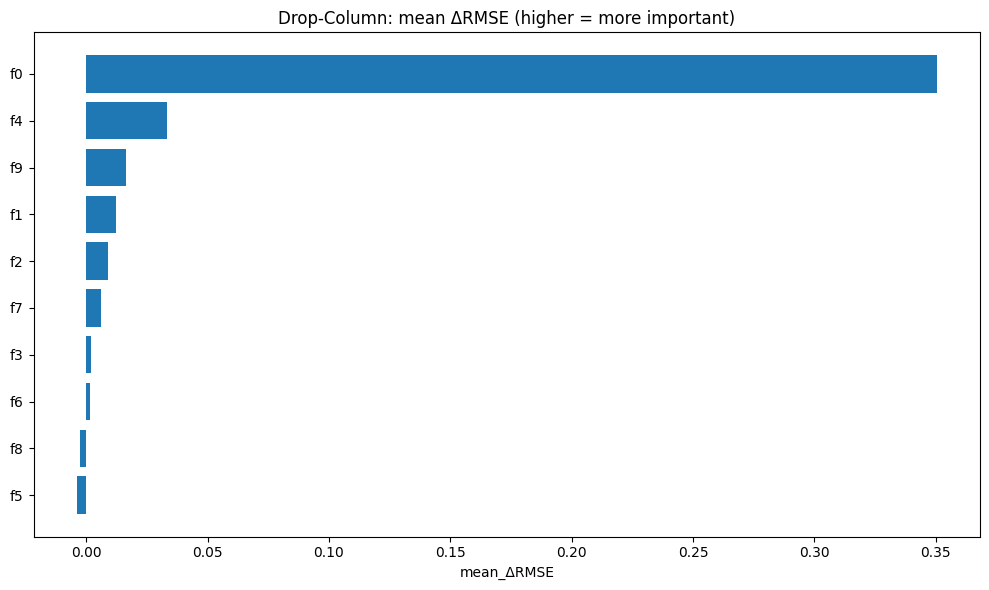

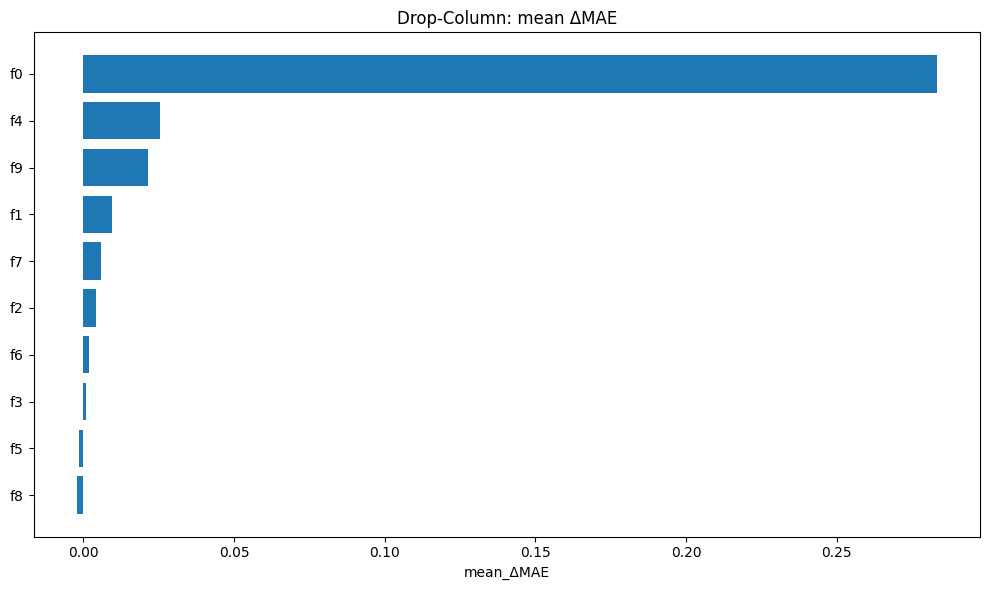

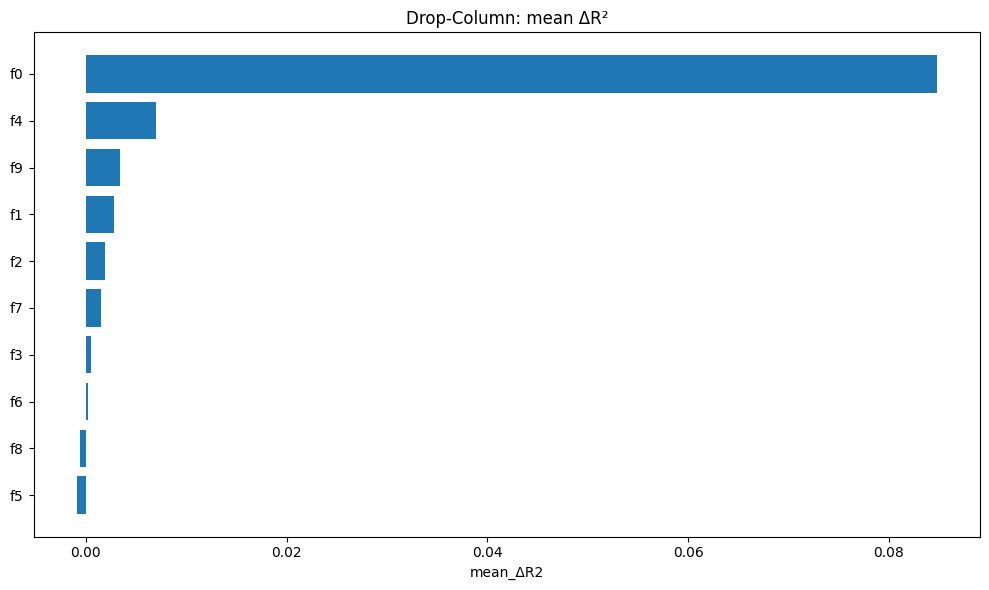

[ARTIFACTS] Saved under: /home/duilio/github/MassBalanceMachine/regions/Chile/dropcol_importance_results/run_20250819_175117
- dropcolumn_importance.csv
- bar_mean_dRMSE.png, bar_mean_dMAE.png, bar_mean_dR2.png


In [ ]:
 ===
# Drop-Column Importance (CV) for Glacier Mass Balance (Regression)
# Importancia por Eliminación de Columna (CV) para Balance de Masa
 ===

import os
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, GroupKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.utils.validation import check_is_fitted

# You must have xgboost installed
# Debes tener xgboost instalado
import xgboost as xgb

# ------------------------------
# 0) Inputs assumed available
# 0) Entradas asumidas como disponibles
# ------------------------------
# - custom_xgboost: tu wrapper con _create_features_metadata
# - df_X_train: DataFrame CRUDO de entrenamiento (con metadata)
# - y_train: vector/Serie objetivo alineado con df_X_train
# - best_estimator: modelo ya ajustado (para clonar hiperparámetros)
#   Nota: NO lo usaremos para .fit, solo para extraer params

best_estimator = custom_xgboost.param_search.best_estimator_

# Optional grouping to avoid leakage across glaciers/years/etc.
# Agrupamiento opcional para evitar leakage entre glaciares/años/etc.
groups_series = None  # e.g., df_X_train['GLACIER_ID'] if available

# ------------------------------------------
# 1) Helper: build features (train/valid fold)
# 1) Helper: construir features (fold train/valid)
# ------------------------------------------
def build_features_from_raw(df_raw):
    # Use your helper to reproduce EXACT features as in training
    # Usa tu helper para reproducir EXACTAMENTE las features del entrenamiento
    X_feat_raw, _ = custom_xgboost._create_features_metadata(df_raw)
    # Ensure we have a DataFrame with column names
    # Asegurar DataFrame con nombres de columna
    if isinstance(X_feat_raw, pd.DataFrame):
        return X_feat_raw.copy()
    X_feat_raw = np.asarray(X_feat_raw)
    cols = [f"f{i}" for i in range(X_feat_raw.shape[1])]
    return pd.DataFrame(X_feat_raw, columns=cols)

# --------------------------------------------------
# 2) Helper: make an XGBRegressor "equivalent" clone
# 2) Helper: crear un XGBRegressor “equivalente”
# --------------------------------------------------
def make_equivalent_xgbregressor(best_estimator):
    # Try to extract xgboost parameters from the fitted wrapper
    # Intentar extraer parámetros xgboost del wrapper entrenado
    params = {}
    # Common attributes in sklearn API
    try:
        params.update(best_estimator.get_xgb_params())
    except Exception:
        try:
            params.update(best_estimator.get_params(deep=False))
        except Exception:
            params = {}
    # Keep only params supported by XGBRegressor
    # Conservar solo params soportados por XGBRegressor
    valid_keys = set(xgb.XGBRegressor().get_params().keys())
    clean = {k: v for k, v in params.items() if k in valid_keys}

    # Make sure important keys propagate (tree_method, n_estimators, etc.)
    # Asegurar que llaves importantes se propaguen (tree_method, n_estimators, etc.)
    booster = best_estimator.get_booster()
    try:
        n_estimators = best_estimator.get_params().get("n_estimators", None)
    except Exception:
        n_estimators = None
    if n_estimators is None:
        # Fallback: trees in booster
        # Respaldo: número de árboles en el booster
        try:
            n_estimators = len(booster.get_dump())
        except Exception:
            n_estimators = 500  # sensible default / default razonable

    clean.setdefault("n_estimators", n_estimators)
    # Ensure objective is regression
    # Asegurar objetivo de regresión
    clean.setdefault("objective", "reg:squarederror")
    # Avoid verbosity spam
    # Evitar verbosidad
    clean.setdefault("verbosity", 0)
    # Device / tree method if present
    # Dispositivo / método de árbol si existe
    if "device" in best_estimator.get_params():
        clean["device"] = best_estimator.get_params()["device"]

    # Build regressor
    # Construir regresor
    reg = xgb.XGBRegressor(**clean)
    return reg

# ------------------------------------------------
# 3) CV splitter and metric helpers
# 3) Particionador de CV y helpers de métricas
# ------------------------------------------------
def rmse(y_true, y_pred):  # physical units of mass balance
    # Unidades físicas del balance de masa
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

n_splits = 5
if groups_series is None:
    splitter = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    split_iter = splitter.split(df_X_train, y_train)
else:
    assert len(groups_series) == len(df_X_train), "groups_series must align with df_X_train"
    splitter = GroupKFold(n_splits=n_splits)
    split_iter = splitter.split(df_X_train, y_train, groups=groups_series)

fold_indices = list(split_iter)

# --------------------------------------------
# 4) Baseline per fold (all features present)
# 4) Baseline por fold (todas las features)
# --------------------------------------------
baseline_scores = []
for k, (tr_idx, va_idx) in enumerate(fold_indices, 1):
    df_tr_raw = df_X_train.iloc[tr_idx]
    df_va_raw = df_X_train.iloc[va_idx]
    ytr = pd.Series(y_train).iloc[tr_idx].values
    yva = pd.Series(y_train).iloc[va_idx].values

    Xtr = build_features_from_raw(df_tr_raw)
    Xva = build_features_from_raw(df_va_raw)

    reg = make_equivalent_xgbregressor(best_estimator)
    # Early stopping if supported
    # Early stopping si se soporta
    try:
        reg.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    except TypeError:
        reg.fit(Xtr, ytr)

    yhat = reg.predict(Xva)
    baseline_scores.append({
        "fold": k,
        "R2":  float(r2_score(yva, yhat)),
        "RMSE": rmse(yva, yhat),
        "MAE":  mae(yva, yhat),
    })

baseline_df = pd.DataFrame(baseline_scores)
print("[BASELINE per fold]\n", baseline_df)
print("[BASELINE mean]\n", baseline_df.mean(numeric_only=True))

# --------------------------------------------
# 5) Drop-Column loop: remove each feature
# 5) Bucle Drop-Column: eliminar cada feature
# --------------------------------------------
# Use the feature space inferred from any fold's Xtr
# Usar el espacio de features inferido del Xtr de cualquier fold
# (Construimos una vez desde todo el df_X_train para nombres estables)
X_all_features = build_features_from_raw(df_X_train)
all_features = list(X_all_features.columns)

results = []
for feat in all_features:
    fold_rows = []
    for k, (tr_idx, va_idx) in enumerate(fold_indices, 1):
        df_tr_raw = df_X_train.iloc[tr_idx]
        df_va_raw = df_X_train.iloc[va_idx]
        ytr = pd.Series(y_train).iloc[tr_idx].values
        yva = pd.Series(y_train).iloc[va_idx].values

        # Build full feature matrices for this fold
        # Construir matrices de features completas para este fold
        Xtr_full = build_features_from_raw(df_tr_raw)
        Xva_full = build_features_from_raw(df_va_raw)

        if feat not in Xtr_full.columns:
            # If feature not present in this fold (shouldn't happen), skip gracefully
            # Si la feature no está en este fold (no debería), saltar
            continue

        # Drop the feature for this fold
        # Eliminar la feature para este fold
        Xtr_drop = Xtr_full.drop(columns=[feat])
        Xva_drop = Xva_full.drop(columns=[feat])

        reg = make_equivalent_xgbregressor(best_estimator)
        try:
            reg.fit(Xtr_drop, ytr, eval_set=[(Xva_drop, yva)], verbose=False)
        except TypeError:
            reg.fit(Xtr_drop, ytr)

        yhat_drop = reg.predict(Xva_drop)

        # Baseline metrics for this fold
        # Métricas baseline para este fold
        base = baseline_df[baseline_df["fold"] == k].iloc[0]
        # Deltas: positive Δ => worse when dropped => important
        # Deltas: Δ positiva => peor al quitar => importante
        fold_rows.append({
            "fold": k,
            "feature": feat,
            "ΔR2":   base["R2"]  - float(r2_score(yva, yhat_drop)),
            "ΔRMSE": float(rmse(yva, yhat_drop)) - base["RMSE"],
            "ΔMAE":  float(mae(yva, yhat_drop))  - base["MAE"],
        })

    if not fold_rows:
        continue
    fdf = pd.DataFrame(fold_rows)
    results.append({
        "feature": feat,
        "mean_ΔR2":   fdf["ΔR2"].mean(),
        "std_ΔR2":    fdf["ΔR2"].std(ddof=1),
        "mean_ΔRMSE": fdf["ΔRMSE"].mean(),
        "std_ΔRMSE":  fdf["ΔRMSE"].std(ddof=1),
        "mean_ΔMAE":  fdf["ΔMAE"].mean(),
        "std_ΔMAE":   fdf["ΔMAE"].std(ddof=1),
    })

dc_df = pd.DataFrame(results).sort_values("mean_ΔRMSE", ascending=False)
print("\n[DROP-COLUMN] Head:\n", dc_df.head(10))

# --------------------------------------------
# 6) Save & plot
# 6) Guardar y graficar
# --------------------------------------------
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
outdir = Path(os.getcwd()) / "dropcol_importance_results" / f"run_{ts}"
outdir.mkdir(parents=True, exist_ok=True)

csv_path = outdir / "dropcolumn_importance.csv"
dc_df.to_csv(csv_path, index=False)
print(f"[INFO] Saved CSV -> {csv_path}")

def plot_bar(df, col, title, fname, topk=None):
    d = df.copy()
    if topk:
        d = d.head(topk)
    plt.figure(figsize=(10, 6))
    plt.barh(d["feature"][::-1], d[col][::-1])
    plt.xlabel(col)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(outdir / fname, dpi=300)
    plt.show()

topk = min(15, len(dc_df))
plot_bar(dc_df, "mean_ΔRMSE", "Drop-Column: mean ΔRMSE (higher = more important)", "bar_mean_dRMSE.png", topk=topk)
plot_bar(dc_df.sort_values("mean_ΔMAE", ascending=False), "mean_ΔMAE", "Drop-Column: mean ΔMAE", "bar_mean_dMAE.png", topk=topk)
plot_bar(dc_df.sort_values("mean_ΔR2", ascending=False), "mean_ΔR2", "Drop-Column: mean ΔR²", "bar_mean_dR2.png", topk=topk)

print(f"[ARTIFACTS] Saved under: {outdir}")
print("- dropcolumn_importance.csv")
print("- bar_mean_dRMSE.png, bar_mean_dMAE.png, bar_mean_dR2.png")

